In [12]:
# Dans votre cellule du notebook, avant d'importer
import sys
sys.path.append(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f\src")

# Puis changer le répertoire
import os
os.chdir(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f")

# Maintenant importer et utiliser
from pass_predictor import PassPredictor
predictor = PassPredictor().load_model()

Modèle XGBoost chargé avec succès
Features utilisées: ['x_passeur', 'y_passeur', 'x_cible', 'y_cible', 'nb_adv_proches_depart', 'nb_adv_trajectoire', 'nb_adv_proches_arrivee', 'nb_coequipiers_proches_arrivee']


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Configuration du style des graphiques
plt.style.use('seaborn-v0_8')

In [8]:
def create_pitch(ax):
    """Crée un terrain de football standardisé (proportions normalisées)"""
    # Terrain (rectangle vert)
    rect = patches.Rectangle((0, 0), 1, 1, linewidth=2, 
                           edgecolor='white', facecolor='#538032', alpha=0.8)
    ax.add_patch(rect)
    
    # Ligne médiane
    plt.plot([0.5, 0.5], [0, 1], color='white', linewidth=2)
    
    # Cercle central
    circle = plt.Circle((0.5, 0.5), 0.1, color='white', fill=False, linewidth=2)
    ax.add_patch(circle)
    
    # Surface de réparation (gauche)
    rect = patches.Rectangle((0, 0.3), 0.18, 0.4, linewidth=2, 
                           edgecolor='white', facecolor='none')
    ax.add_patch(rect)
    
    # Surface de but (gauche)
    rect = patches.Rectangle((0, 0.4), 0.06, 0.2, linewidth=2, 
                           edgecolor='white', facecolor='none')
    ax.add_patch(rect)
    
    # Surface de réparation (droite)
    rect = patches.Rectangle((0.82, 0.3), 0.18, 0.4, linewidth=2, 
                           edgecolor='white', facecolor='none')
    ax.add_patch(rect)
    
    # Surface de but (droite)
    rect = patches.Rectangle((0.94, 0.4), 0.06, 0.2, linewidth=2, 
                           edgecolor='white', facecolor='none')
    ax.add_patch(rect)
    
    # Ajuster les paramètres du graphique
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    
    return ax

def plot_pass_success_probability(ax, origin_x, origin_y, target_x, target_y, prob, annotate=True):
    """Affiche une passe et sa probabilité de réussite"""
    # Tracer la passe (flèche)
    arrow = ax.arrow(origin_x, origin_y, target_x-origin_x, target_y-origin_y, 
                   head_width=0.02, head_length=0.03, fc='black', ec='black',
                   length_includes_head=True, alpha=0.7)
    
    # Afficher la probabilité
    if annotate:
        mid_x = (origin_x + target_x) / 2
        mid_y = (origin_y + target_y) / 2
        ax.annotate(f"{prob:.0%}", (mid_x, mid_y), 
                  bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
                  fontsize=10, ha='center', va='center')
    
    return arrow

def plot_player(ax, x, y, team='home', label=None):
    """Affiche un joueur sur le terrain"""
    if team == 'home':
        color = 'blue'
    elif team == 'away':
        color = 'red'
    else:
        color = 'gray'
    
    circle = ax.scatter(x, y, s=200, color=color, edgecolor='black', zorder=3, 
                      alpha=0.8, label=label)
    
    if label:
        ax.annotate(label, (x, y), fontsize=8, ha='center', va='center',
                  color='white', fontweight='bold', zorder=4)
    
    return circle

TypeError: PassPredictor.predict_single_pass() got an unexpected keyword argument 'nb_adv_proches_depart'

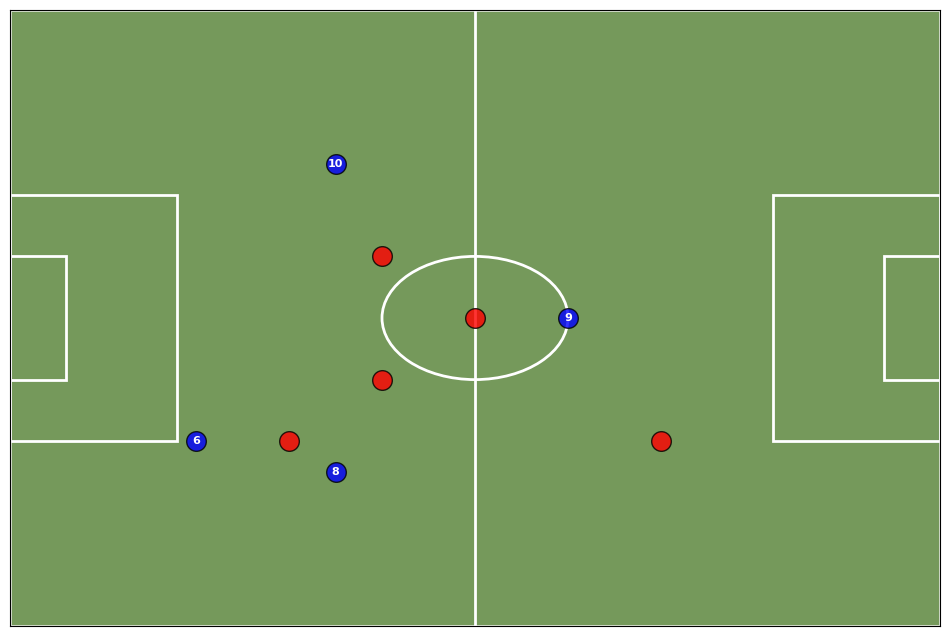

In [9]:
# Créer la figure
fig, ax = plt.subplots(figsize=(12, 8))
create_pitch(ax)

# Positionnement des joueurs
# Équipe à domicile (bleu)
plot_player(ax, 0.2, 0.3, 'home', '6')  # Milieu défensif
plot_player(ax, 0.35, 0.25, 'home', '8')  # Milieu central 
plot_player(ax, 0.35, 0.75, 'home', '10')  # Milieu offensif
plot_player(ax, 0.6, 0.5, 'home', '9')  # Attaquant

# Équipe adverse (rouge)
plot_player(ax, 0.3, 0.3, 'away', '')  
plot_player(ax, 0.4, 0.4, 'away', '')
plot_player(ax, 0.4, 0.6, 'away', '')
plot_player(ax, 0.5, 0.5, 'away', '')
plot_player(ax, 0.7, 0.3, 'away', '')

# Calculer les probabilités de passe pour différentes cibles
pass_origin = (0.2, 0.3)  # Position du joueur 6

targets = [
    {"pos": (0.35, 0.25), "label": "Milieu central"},
    {"pos": (0.35, 0.75), "label": "Milieu offensif"},
    {"pos": (0.6, 0.5), "label": "Attaquant"}
]

for target in targets:
    # Paramètres de la situation
    target_pos = target["pos"]
    
    # Compter les adversaires proches du passeur
    adv_proches_depart = sum(1 for x, y in [(0.3, 0.3)] if 
                           np.sqrt((x-pass_origin[0])**2 + (y-pass_origin[1])**2) < 0.1)
    
    # Compter les adversaires sur la trajectoire
    adv_trajectoire = 1 if target["label"] == "Attaquant" else 0
    
    # Compter les adversaires proches de la cible
    adv_proches_arrivee = sum(1 for x, y in [(0.4, 0.4), (0.4, 0.6), (0.5, 0.5), (0.7, 0.3)] if 
                           np.sqrt((x-target_pos[0])**2 + (y-target_pos[1])**2) < 0.1)
    
    # Compter les coéquipiers proches de la cible (excluant la cible elle-même)
    coequipiers_proches_arrivee = 0
    
    # Prédire la probabilité de succès
    prob = predictor.predict_single_pass(
        x_passeur=pass_origin[0], y_passeur=pass_origin[1],
        x_cible=target_pos[0], y_cible=target_pos[1],
        nb_adv_proches_depart=adv_proches_depart,
        nb_adv_trajectoire=adv_trajectoire,
        nb_adv_proches_arrivee=adv_proches_arrivee,
        nb_coequipiers_proches_arrivee=coequipiers_proches_arrivee
    )
    
    # Afficher la passe et sa probabilité
    plot_pass_success_probability(ax, pass_origin[0], pass_origin[1], 
                               target_pos[0], target_pos[1], prob)

plt.title("Scénario 1: Probabilité des passes de progression depuis l'arrière", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# 🔍 CELLULE DE DIAGNOSTIC - À exécuter en premier
import os
import glob
import sys

print("🔍 DIAGNOSTIC DU SYSTÈME")
print("=" * 50)

# Vérifier le répertoire et les fichiers
print(f"📁 Répertoire actuel: {os.getcwd()}")
print(f"📋 Fichiers .pkl dans le répertoire:")
pkl_files = glob.glob("*.pkl")
for file in pkl_files:
    print(f"  ✓ {file}")

# Vérifier les imports
try:
    from Pass_chances_function import distance
    print("✅ Pass_chances_function importé avec succès")
except ImportError as e:
    print(f"❌ Erreur import Pass_chances_function: {e}")

try:
    from pass_predictor import PassPredictor
    print("✅ pass_predictor importé avec succès")
except ImportError as e:
    print(f"❌ Erreur import pass_predictor: {e}")

print("=" * 50)

🔍 DIAGNOSTIC DU SYSTÈME
📁 Répertoire actuel: c:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f\src
📋 Fichiers .pkl dans le répertoire:
✅ Pass_chances_function importé avec succès
✅ pass_predictor importé avec succès


In [9]:
# Votre première cellule existante
import sys
import os
sys.path.append(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f\src")
os.chdir(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f")

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import pickle
import json

from Pass_chances_function import (
    distance, nb_adv_proches_coords, nb_adv_trajectoire_coords,
    nb_coequipiers_trajectoire, densite_adversaires_ponderee,
    densite_adversaires_inverse, get_zone
)

def load_best_hyperparameters():

    """Charge les hyperparamètres optimisés par Optuna depuis le fichier pkl"""
    try:
        # Charger depuis le fichier pkl créé par Optuna (dans le dossier racine)
        with open('../hyperparameter_optimization_results.pkl', 'rb') as f:
            optuna_results = pickle.load(f)
        
        best_params = optuna_results['best_params']
        best_value = optuna_results['best_value']
        
        print("✅ Hyperparamètres Optuna chargés avec succès")
        print(f"   Score d'optimisation: {best_value:.4f}")
        print(f"   Paramètres: {best_params}")
        
        return best_params
        
    except FileNotFoundError:
        print("⚠️ Fichier hyperparameter_optimization_results.pkl non trouvé")
        print("   Utilisation des valeurs par défaut")
        # Valeurs par défaut si le fichier n'existe pas
        return {
            'sigma': 0.05,
            'seuil_trajectoire': 0.02,
            'x_divisions': 15,
            'y_divisions': 10
        }
    except Exception as e:
        print(f"❌ Erreur lors du chargement des hyperparamètres: {e}")
        return {
            'sigma': 0.05,
            'seuil_trajectoire': 0.02,
            'x_divisions': 15,
            'y_divisions': 10
        }

def print_hyperparameters_info():
    """Affiche les hyperparamètres actuellement utilisés"""
    params = load_best_hyperparameters()
    
    print("=" * 45)
    print("    HYPERPARAMÈTRES OPTUNA UTILISÉS")
    print("=" * 45)
    for key, value in params.items():
        print(f"{key:20}: {value}")
    print("=" * 45)

def calculate_pass_features(x_passeur, y_passeur, x_cible, y_cible, 
                          adv_positions, teammate_positions, 
                          x_divisions=15, y_divisions=10):
    """
    Calcule toutes les features d'une passe en utilisant les hyperparamètres optimisés par Optuna
    """
    # ⭐ CHARGER LES HYPERPARAMÈTRES OPTIMAUX D'OPTUNA
    best_params = load_best_hyperparameters()
    
    # Utiliser les valeurs optimisées ou les paramètres par défaut
    sigma_optimal = best_params.get('sigma', 0.05)
    seuil_trajectoire_optimal = best_params.get('seuil_trajectoire', 0.02)
    x_div_optimal = best_params.get('x_divisions', x_divisions)
    y_div_optimal = best_params.get('y_divisions', y_divisions)
    
    # Features de base
    distance_passe = distance(x_passeur, y_passeur, x_cible, y_cible)
    
    # Sens de la passe (vers l'avant = positif)
    sens_passe = 1 if x_cible > x_passeur else -1
    
    # ⭐ UTILISER LES HYPERPARAMÈTRES OPTIMAUX
    # Adversaires proches du départ (densité pondérée avec sigma optimal)
    nb_adv_proches_depart = densite_adversaires_ponderee(
        x_passeur, y_passeur, adv_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Adversaires sur la trajectoire (avec seuil optimal)
    nb_adv_trajectoire = nb_adv_trajectoire_coords(
        x_passeur, y_passeur, x_cible, y_cible, adv_positions, 
        seuil_trajectoire=seuil_trajectoire_optimal  # ← Valeur optimisée par Optuna
    )

    # Coéquipiers sur la trajectoire
    nb_coequipiers_trajectoire = nb_adv_trajectoire_coords(
        x_passeur, y_passeur, x_cible, y_cible, teammate_positions, 
        seuil_trajectoire=seuil_trajectoire_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Adversaires proches de l'arrivée (densité pondérée avec sigma optimal)
    nb_adv_proches_arrivee = densite_adversaires_ponderee(
        x_cible, y_cible, adv_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Coéquipiers proches de l'arrivée
    nb_coequipiers_proches_arrivee = densite_adversaires_ponderee(
        x_cible, y_cible, teammate_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Créer le dictionnaire des features (exactement comme vous l'avez défini)
    features = {
        'distance_passe': distance_passe,
        'sens_passe': sens_passe,
        'nb_adv_proches_depart': nb_adv_proches_depart,
        'nb_adv_trajectoire': nb_adv_trajectoire,
        'nb_coequipiers_trajectoire': nb_coequipiers_trajectoire,
        'nb_adv_proches_arrivee': nb_adv_proches_arrivee,
        'nb_coequipiers_proches_arrivee': nb_coequipiers_proches_arrivee,
    }
    
    return features
# Import des fonctions depuis Pass_chances_function.py

def create_situation(situation_name):
    """
    Crée différentes situations de jeu avec 22 joueurs (11 vs 11)
    
    Returns:
        dict: Contient passeur, adversaires, coéquipiers et titre
    """
    situations = {
        'aile_droite': {
            'passeur': (0.65, 0.3),
            'adversaires': np.array([
                # Équipe adverse complète (11 joueurs)
                [0.9, 0.5],    # Gardien
                [0.8, 0.2],    # Défenseur droit
                [0.8, 0.35],   # Défenseur central droit
                [0.8, 0.65],   # Défenseur central gauche
                [0.8, 0.8],    # Défenseur gauche
                [0.6, 0.25],   # Milieu droit
                [0.6, 0.45],   # Milieu central défensif
                [0.6, 0.55],   # Milieu central offensif
                [0.6, 0.75],   # Milieu gauche
                [0.3, 0.4],    # Attaquant droit
                [0.3, 0.6],    # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Équipe à domicile (10 joueurs, sans le passeur)
                [0.1, 0.5],    # Gardien
                [0.2, 0.2],    # Défenseur droit
                [0.2, 0.35],   # Défenseur central droit
                [0.2, 0.65],   # Défenseur central gauche
                [0.2, 0.8],    # Défenseur gauche
                [0.4, 0.45],   # Milieu central défensif
                [0.4, 0.55],   # Milieu central offensif
                [0.4, 0.75],   # Milieu gauche
                [0.7, 0.4],    # Attaquant droit
                [0.7, 0.6],    # Attaquant gauche
            ]),
            'title': "Situation depuis l'aile droite (22 joueurs)"
        },
        
        'milieu_terrain': {
            'passeur': (0.5, 0.5),
            'adversaires': np.array([
                # Équipe adverse complète
                [0.9, 0.5],    # Gardien
                [0.8, 0.15],   # Défenseur droit
                [0.8, 0.35],   # Défenseur central droit
                [0.8, 0.65],   # Défenseur central gauche
                [0.8, 0.85],   # Défenseur gauche
                [0.65, 0.3],   # Milieu droit
                [0.65, 0.7],   # Milieu gauche
                [0.55, 0.45],  # Milieu défensif
                [0.55, 0.55],  # Milieu offensif
                [0.3, 0.4],    # Attaquant droit
                [0.3, 0.6],    # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Équipe à domicile (sans le passeur au milieu)
                [0.1, 0.5],    # Gardien
                [0.2, 0.15],   # Défenseur droit
                [0.2, 0.35],   # Défenseur central droit
                [0.2, 0.65],   # Défenseur central gauche
                [0.2, 0.85],   # Défenseur gauche
                [0.35, 0.3],   # Milieu droit
                [0.35, 0.7],   # Milieu gauche
                [0.45, 0.45],  # Milieu défensif
                [0.7, 0.4],    # Attaquant droit
                [0.7, 0.6],    # Attaquant gauche
            ]),
            'title': "Situation depuis le milieu de terrain (22 joueurs)"
        },
        
        'corner_kick': {
            'passeur': (0.98, 0.1),
            'adversaires': np.array([
                # Défense en bloc dans la surface
                [0.1, 0.5],    # Gardien adverse (dans ses buts)
                [0.85, 0.25],  # Défenseur sur le poteau proche
                [0.88, 0.35],  # Défenseur central
                [0.9, 0.45],   # Défenseur central
                [0.88, 0.55],  # Défenseur central
                [0.85, 0.65],  # Défenseur central
                [0.86, 0.75],  # Défenseur sur le poteau lointain
                [0.8, 0.4],    # Milieu défensif
                [0.8, 0.6],    # Milieu défensif
                [0.75, 0.3],   # Milieu en couverture
                [0.75, 0.7],   # Milieu en couverture
            ]),
            'coequipiers': np.array([
                # Équipe offensive sur corner
                [0.1, 0.5],    # Gardien reste dans ses buts
                [0.3, 0.5],    # Défenseur reste en couverture
                [0.4, 0.5],    # Autre défenseur en couverture
                [0.9, 0.3],    # Attaquant dans la surface
                [0.88, 0.45],  # Attaquant au centre
                [0.9, 0.6],    # Attaquant dans la surface
                [0.85, 0.4],   # Attaquant près du gardien
                [0.87, 0.55],  # Attaquant au second poteau
                [0.82, 0.5],   # Attaquant au point de penalty
                [0.75, 0.45],  # Milieu à l'entrée de la surface
            ]),
            'title': "Corner - 22 joueurs positionnés"
        },
        
        'defense_profonde': {
            'passeur': (0.2, 0.5),
            'adversaires': np.array([
                # Pressing haut de l'équipe adverse
                [0.9, 0.5],    # Gardien adverse
                [0.35, 0.25],  # Défenseur monté
                [0.35, 0.45],  # Défenseur central monté
                [0.35, 0.55],  # Défenseur central monté
                [0.35, 0.75],  # Défenseur monté
                [0.45, 0.3],   # Milieu en pressing
                [0.45, 0.7],   # Milieu en pressing
                [0.5, 0.45],   # Milieu offensif en pressing
                [0.5, 0.55],   # Milieu offensif en pressing
                [0.6, 0.4],    # Attaquant en pressing
                [0.6, 0.6],    # Attaquant en pressing
            ]),
            'coequipiers': np.array([
                # Équipe en défense profonde
                [0.1, 0.5],    # Gardien
                [0.15, 0.25],  # Défenseur droit
                [0.15, 0.35],  # Défenseur central droit
                [0.15, 0.65],  # Défenseur central gauche
                [0.15, 0.75],  # Défenseur gauche
                [0.25, 0.4],   # Milieu défensif
                [0.25, 0.6],   # Milieu défensif
                [0.4, 0.3],    # Milieu droit replié
                [0.4, 0.7],    # Milieu gauche replié
                [0.5, 0.5],    # Attaquant seul devant
            ]),
            'title': "Relance depuis la défense sous pressing (22 joueurs)"
        },
        
        'contre_attaque': {
            'passeur': (0.4, 0.4),
            'adversaires': np.array([
                # Équipe adverse déséquilibrée
                [0.9, 0.5],    # Gardien
                [0.3, 0.3],    # Dernier défenseur
                [0.3, 0.7],    # Autre défenseur
                [0.2, 0.45],   # Défenseur central en retard
                [0.2, 0.55],   # Défenseur central en retard
                [0.15, 0.25],  # Défenseur latéral très haut
                [0.15, 0.75],  # Défenseur latéral très haut
                [0.1, 0.4],    # Milieu très avancé
                [0.1, 0.6],    # Milieu très avancé
                [0.05, 0.45],  # Attaquant très haut
                [0.05, 0.55],  # Attaquant très haut
            ]),
            'coequipiers': np.array([
                # Équipe en contre-attaque
                [0.1, 0.5],    # Gardien
                [0.25, 0.2],   # Défenseur droit
                [0.25, 0.35],  # Défenseur central
                [0.25, 0.65],  # Défenseur central
                [0.25, 0.8],   # Défenseur gauche
                [0.35, 0.5],   # Milieu défensif
                [0.6, 0.3],    # Attaquant en course
                [0.7, 0.2],    # Ailier lancé
                [0.75, 0.6],   # Autre attaquant
                [0.5, 0.5],    # Soutien milieu
            ]),
            'title': "Contre-attaque rapide (22 joueurs)"
        },
        
        'surface_reparation': {
            'passeur': (0.82, 0.3),
            'adversaires': np.array([
                # Défense resserrée dans la surface
                [0.9, 0.5],    # Gardien
                [0.88, 0.35],  # Défenseur proche
                [0.86, 0.45],  # Défenseur central
                [0.88, 0.55],  # Défenseur central
                [0.85, 0.65],  # Défenseur éloigné
                [0.8, 0.4],    # Milieu défensif
                [0.8, 0.6],    # Milieu défensif
                [0.75, 0.35],  # Milieu en couverture
                [0.75, 0.65],  # Milieu en couverture
                [0.4, 0.4],    # Attaquant adverse replié
                [0.4, 0.6],    # Attaquant adverse replié
            ]),
            'coequipiers': np.array([
                # Équipe offensive dans la surface
                [0.1, 0.5],    # Gardien
                [0.2, 0.5],    # Défenseur en couverture
                [0.3, 0.3],    # Défenseur monté
                [0.3, 0.7],    # Défenseur monté
                [0.5, 0.4],    # Milieu offensif
                [0.5, 0.6],    # Milieu offensif
                [0.75, 0.25],  # Ailier
                [0.85, 0.2],   # Attaquant démarqué
                [0.88, 0.4],   # Attaquant au centre
                [0.87, 0.65],  # Attaquant côté opposé
            ]),
            'title': "Dans la surface de réparation adverse (22 joueurs)"
        }
    }
    
    return situations.get(situation_name, situations['milieu_terrain'])


def create_pass_heatmap(origin_x, origin_y, adv_positions, teammate_positions, predictor, 
                       x_divisions=15, y_divisions=10):
    """
    Version mise à jour utilisant les fonctions de Pass_chances_function.py
    """
    # Créer une grille de positions cibles
    x_grid = np.linspace(0.05, 0.95, 30)
    y_grid = np.linspace(0.05, 0.95, 20)
    
    # Initialiser la matrice de probabilités
    prob_matrix = np.zeros((len(y_grid), len(x_grid)))
    
    # Pour chaque position cible possible
    for i, target_y in enumerate(y_grid):
        for j, target_x in enumerate(x_grid):
            
            # Calculer toutes les features avec les fonctions existantes
            features = calculate_pass_features(
                origin_x, origin_y, target_x, target_y,
                adv_positions, teammate_positions,
                x_divisions, y_divisions
            )
            
            # Créer un DataFrame avec les features
            feature_df = pd.DataFrame([features])
            
            # Prédire la probabilité
            prob = predictor.predict_proba(feature_df)[0, 1]  # Probabilité classe positive
            prob_matrix[i, j] = prob
    
    return x_grid, y_grid, prob_matrix

def plot_situation_heatmap(situation_name, predictor, figsize=(12, 8)):
    """
    Affiche une carte de chaleur pour une situation donnée
    """
    # Récupérer la situation
    situation = create_situation(situation_name)
    
    # Configuration
    fig, ax = plt.subplots(figsize=figsize)
    create_pitch(ax)
    
    # Extraire les données
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    # Afficher les joueurs
    plot_player(ax, origin_x, origin_y, 'home', '10')  # Passeur avec numéro
    
    for i, (x, y) in enumerate(adv_positions):
        plot_player(ax, x, y, 'away')
    
    for i, (x, y) in enumerate(teammate_positions):
        plot_player(ax, x, y, 'home')
    
    # Créer et afficher la carte de chaleur
    x_grid, y_grid, prob_matrix = create_pass_heatmap(
        origin_x, origin_y, adv_positions, teammate_positions, predictor
    )
    
    X, Y = np.meshgrid(x_grid, y_grid)
    cmap = LinearSegmentedColormap.from_list('custom', ['red', 'yellow', 'green'], N=100)
    contour = ax.contourf(X, Y, prob_matrix, levels=50, cmap=cmap, alpha=0.6)
    
    # Ajouter des contours pour plus de clarté
    ax.contour(X, Y, prob_matrix, levels=[0.2, 0.5, 0.8], colors='black', linewidths=0.5, alpha=0.7)
    
    # Légende
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Probabilité de succès de passe', rotation=270, labelpad=20)
    
    plt.title(situation['title'], fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    return fig, ax

def analyze_pass_features_for_situation(situation_name):
    """
    Analyse les features pour une situation donnée
    """
    situation = create_situation(situation_name)
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    print(f"\n=== Analyse des features pour: {situation['title']} ===")
    print(f"Position du passeur: ({origin_x:.2f}, {origin_y:.2f})")
    print(f"Nombre d'adversaires: {len(adv_positions)}")
    print(f"Nombre de coéquipiers: {len(teammate_positions)}")
    
    # Analyser quelques positions cibles
    test_targets = [
        (0.7, 0.3, "Avant-droit"),
        (0.8, 0.5, "Centre-avant"),
        (0.7, 0.7, "Avant-gauche")
    ]
    
    for target_x, target_y, label in test_targets:
        features = calculate_pass_features(
            origin_x, origin_y, target_x, target_y,
            adv_positions, teammate_positions
        )
        
        print(f"\n--- Cible: {label} ({target_x:.2f}, {target_y:.2f}) ---")
        print(f"Distance: {features['distance_passe']:.3f}")
        print(f"Sens: {features['sens_passe']:.3f}")
        print(f"Adv. proches départ: {features['nb_adv_proches_depart']}")
        print(f"Adv. sur trajectoire: {features['nb_adv_trajectoire']}")
        print(f"Adv. proches arrivée: {features['nb_adv_proches_arrivee']}")
        print(f"Coéq. proches arrivée: {features['nb_coequipiers_proches_arrivee']}")
        print(f"Densité adv. départ: {features['densite_adv_depart']:.3f}")
        print(f"Densité adv. arrivée: {features['densite_adv_arrivee']:.3f}")

# Fonction utilitaire pour tester une passe spécifique
def test_single_pass(x_passeur, y_passeur, x_cible, y_cible, 
                    adv_positions, teammate_positions, predictor):
    """
    Teste une passe spécifique et retourne la probabilité avec les détails
    """
    features = calculate_pass_features(
        x_passeur, y_passeur, x_cible, y_cible,
        adv_positions, teammate_positions
    )
    
    feature_df = pd.DataFrame([features])
    prob = predictor.predict_proba(feature_df)[0, 1]
    
    return prob, features

In [17]:
# 🤖 CHARGEMENT SÉCURISÉ DU PRÉDICTEUR
def load_predictor_safely():
    """Charge le prédicteur avec fallback"""
    try:
        from pass_predictor import PassPredictor
        predictor = PassPredictor().load_model()
        print("✅ PassPredictor chargé avec succès")
        return predictor, "PassPredictor"
    except Exception as e:
        print(f"⚠️ Erreur PassPredictor: {e}")
        print("💡 Utilisation d'un prédicteur simple")
        
        # Prédicteur simple de secours
        class SimplePassPredictor:
            def predict_proba(self, feature_df):
                probabilities = []
                for _, row in feature_df.iterrows():
                    base_prob = 0.7
                    distance_penalty = min(row['distance_passe'] * 0.3, 0.4)
                    adv_penalty = (row.get('nb_adv_proches_depart', 0) * 0.1 + 
                                  row.get('nb_adv_trajectoire', 0) * 0.15 + 
                                  row.get('nb_adv_proches_arrivee', 0) * 0.1)
                    prob = max(0.05, min(0.95, base_prob - distance_penalty - adv_penalty))
                    probabilities.append([1-prob, prob])
                return np.array(probabilities)
        
        return SimplePassPredictor(), "SimplePredictor"

# Charger le prédicteur
predictor, predictor_type = load_predictor_safely()
print(f"🎯 Prédicteur utilisé: {predictor_type}")

Paramètres optimaux chargés: {'sigma': 0.020264979108142053, 'seuil_trajectoire': 0.016622456647036446}
❌ Erreur chargement best_pass_model_xgb.json: 'super' object has no attribute '__sklearn_tags__'
⚠️ Erreur PassPredictor: Aucun modèle best_pass_model_* trouvé
💡 Utilisation d'un prédicteur simple
🎯 Prédicteur utilisé: SimplePredictor


In [14]:
# 🧪 TEST DES HYPERPARAMÈTRES
print("🔍 VÉRIFICATION DES HYPERPARAMÈTRES")
print_hyperparameters_info()

# Test d'une prédiction simple
print("\n🧪 Test d'une prédiction:")
try:
    situation = create_situation('aile_droite')
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']

    features = calculate_pass_features(
        origin_x, origin_y, 0.8, 0.4,
        adv_positions, teammate_positions
    )
    
    print("✅ Features calculées:")
    for key, value in features.items():
        print(f"  {key}: {value:.3f}" if isinstance(value, float) else f"  {key}: {value}")
    
    # Test de prédiction
    feature_df = pd.DataFrame([features])
    prob = predictor.predict_proba(feature_df)[0, 1]
    print(f"✅ Prédiction réussie: {prob:.1%}")
    
except Exception as e:
    print(f"❌ Erreur: {e}")
    import traceback
    traceback.print_exc()

🔍 VÉRIFICATION DES HYPERPARAMÈTRES
⚠️ Fichier hyperparameter_optimization_results.pkl non trouvé
   Utilisation des valeurs par défaut
    HYPERPARAMÈTRES OPTUNA UTILISÉS
sigma               : 0.05
seuil_trajectoire   : 0.02
x_divisions         : 15
y_divisions         : 10

🧪 Test d'une prédiction:
⚠️ Fichier hyperparameter_optimization_results.pkl non trouvé
   Utilisation des valeurs par défaut
✅ Features calculées:
  distance_passe: 0.180
  sens_passe: 1
  nb_adv_proches_depart: 0.383
  nb_adv_trajectoire: 0
  nb_coequipiers_trajectoire: 0
  nb_adv_proches_arrivee: 0.625
  nb_coequipiers_proches_arrivee: 0.135
❌ Erreur: 'PassPredictor' object has no attribute 'predict_proba'


Traceback (most recent call last):
  File "C:\Users\az_ta\AppData\Local\Temp\ipykernel_5476\952734454.py", line 24, in <module>
    prob = predictor.predict_proba(feature_df)[0, 1]
           ^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'PassPredictor' object has no attribute 'predict_proba'


Paramètres optimaux chargés: {'sigma': 0.02950813200199715, 'seuil_trajectoire': 0.011119226419740075, 'x_divisions': 23, 'y_divisions': 10}
✓ Modèle XGBoost chargé depuis best_pass_model_xgb.json
✓ Métadonnées chargées avec succès
Features utilisées: ['distance_passe', 'sens_passe', 'nb_adv_proches_depart', 'nb_adv_trajectoire', 'nb_adv_proches_arrivee', 'nb_coequipiers_proches_arrivee']
Génération de la carte pour: aile_droite
⚠️ Fichier hyperparameter_optimization_results.pkl non trouvé
   Utilisation des valeurs par défaut


AttributeError: 'PassPredictor' object has no attribute 'predict_proba'

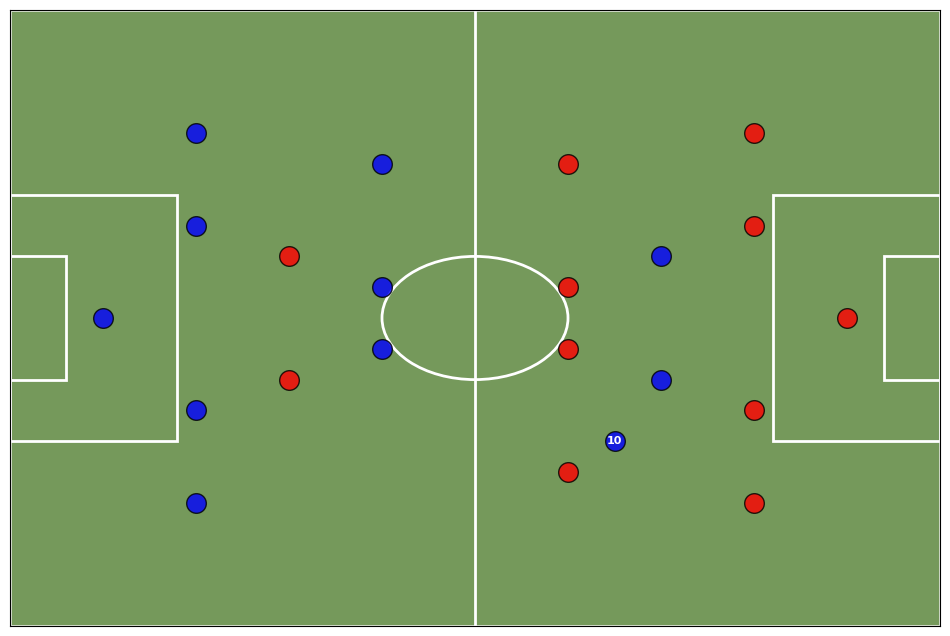

In [15]:
# Charger votre prédicteur (assurez-vous qu'il est disponible)
from pass_predictor import PassPredictor
predictor = PassPredictor().load_model()

# Afficher différentes situations
situations_to_show = [
    'aile_droite',
    'milieu_terrain', 
    'corner_kick',
    'defense_profonde',
    'contre_attaque',
    'surface_reparation'
]

# Créer toutes les visualisations
for situation in situations_to_show:
    print(f"Génération de la carte pour: {situation}")
    plot_situation_heatmap(situation, predictor)

🏈 Visualisation des Expected Goals (xG) sur le terrain

1. Calcul et affichage de la heatmap xG...
Calcul des valeurs xG pour chaque zone...


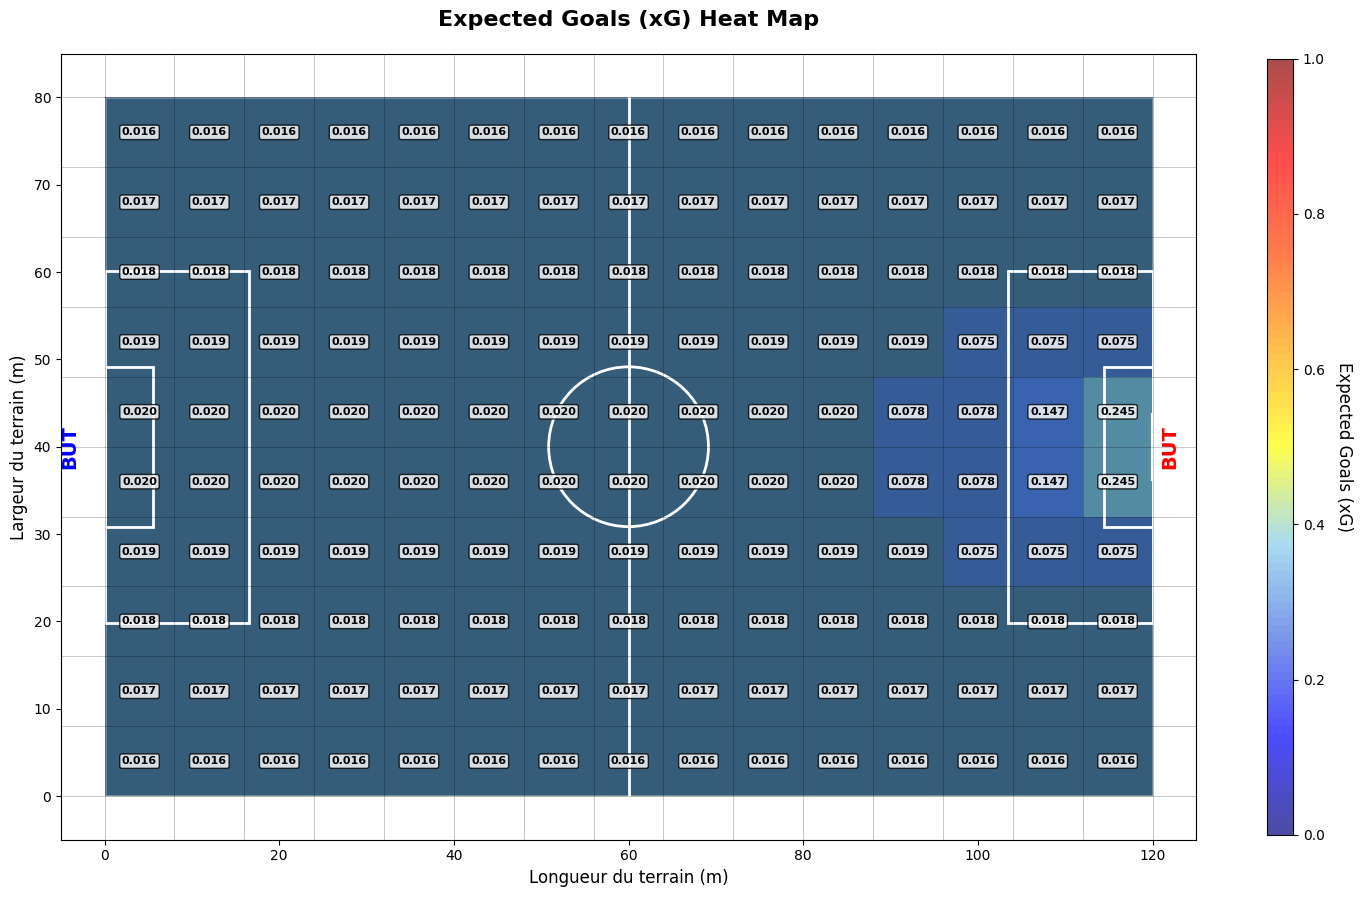


2. Analyse statistique des zones...
=== Analyse des zones xG ===
Valeur xG maximale: 0.245
Valeur xG minimale: 0.016
Valeur xG moyenne: 0.027
Valeur xG médiane: 0.018

=== Top 5 des meilleures zones pour tirer ===
1. Zone (15, 5) - Position: (116.0m, 36.0m)
   xG: 0.245, Distance au but: 7.2m
2. Zone (15, 6) - Position: (116.0m, 44.0m)
   xG: 0.245, Distance au but: 7.2m
3. Zone (14, 6) - Position: (108.0m, 44.0m)
   xG: 0.147, Distance au but: 13.4m
4. Zone (14, 5) - Position: (108.0m, 36.0m)
   xG: 0.147, Distance au but: 13.4m
5. Zone (12, 5) - Position: (92.0m, 36.0m)
   xG: 0.078, Distance au but: 28.6m

3. Comparaison des prédicteurs...
⚠️ Impossible de charger le modèle entraîné: [Errno 2] No such file or directory: 'xg_model_metadata.pkl'
Utilisation uniquement de la fonction simple
Calcul de la heatmap avec fonction simple...
Calcul des valeurs xG pour chaque zone...


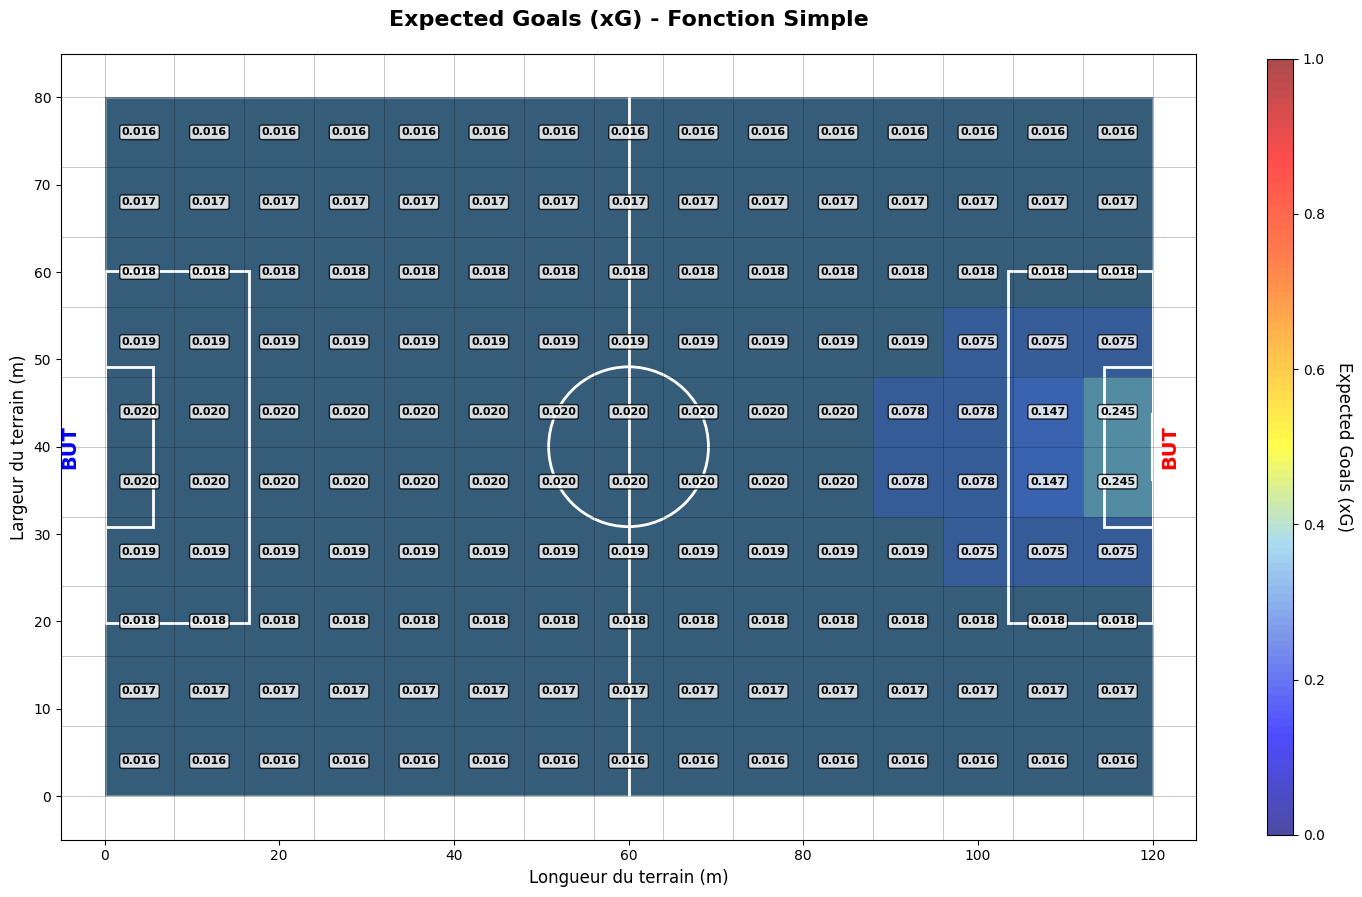


4. Heatmap haute résolution (20x15 zones)...
Calcul des valeurs xG pour chaque zone...


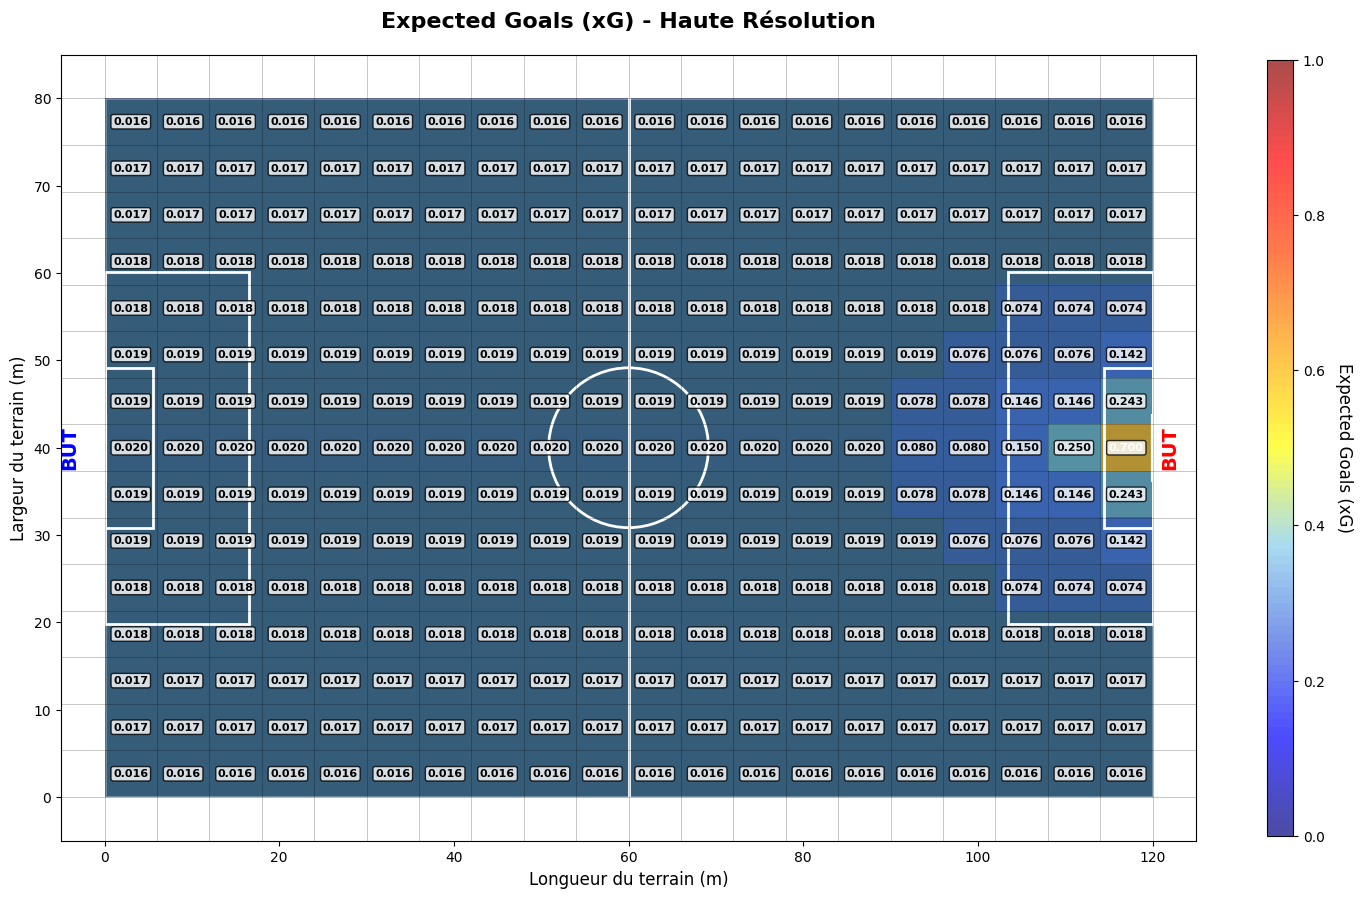


5. Visualisation 3D...


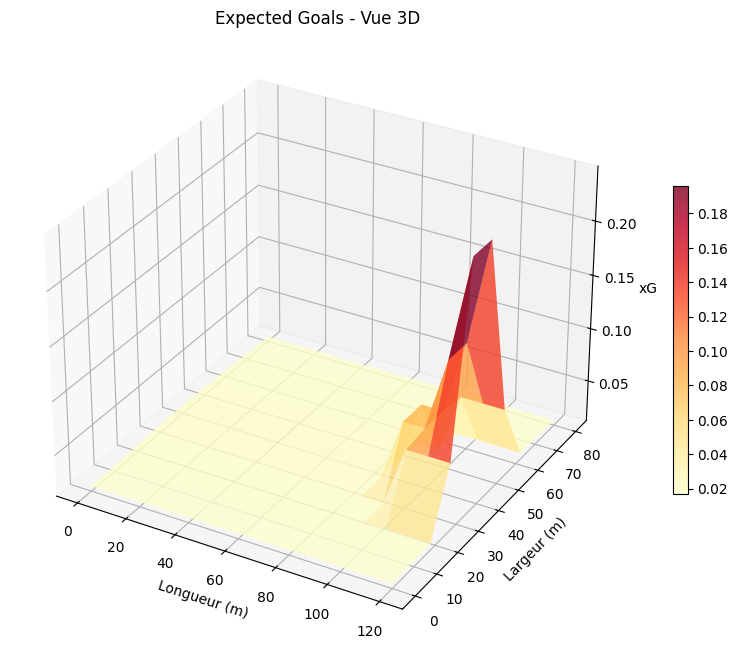


✅ Visualisation terminée!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Import du shot predictor
import sys
sys.path.append('c:/Users/az_ta/Documents/Stage 3A Japon/Determiner_f/src')
from shot_predictor import simple_xg_function, XGPredictor, distance_but, get_zone

# Paramètres du terrain et des zones
FIELD_LENGTH = 120  # mètres
FIELD_WIDTH = 80    # mètres
X_DIVISIONS = 15
Y_DIVISIONS = 10

def create_field_visualization():
    """Crée la visualisation du terrain de football"""
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Dessiner le terrain
    field = patches.Rectangle((0, 0), FIELD_LENGTH, FIELD_WIDTH, 
                             linewidth=2, edgecolor='white', facecolor='green', alpha=0.3)
    ax.add_patch(field)
    
    # Ligne médiane
    ax.axvline(x=FIELD_LENGTH/2, color='white', linewidth=2)
    
    # Cercle central
    center_circle = patches.Circle((FIELD_LENGTH/2, FIELD_WIDTH/2), 9.15, 
                                  linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(center_circle)
    
    # Surface de réparation droite (but à droite)
    penalty_box = patches.Rectangle((FIELD_LENGTH-16.5, FIELD_WIDTH/2-20.15), 16.5, 40.3,
                                   linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(penalty_box)
    
    # Surface de but droite
    goal_box = patches.Rectangle((FIELD_LENGTH-5.5, FIELD_WIDTH/2-9.16), 5.5, 18.32,
                                linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(goal_box)
    
    # But droit
    goal = patches.Rectangle((FIELD_LENGTH, FIELD_WIDTH/2-3.66), 2, 7.32,
                            linewidth=3, edgecolor='white', facecolor='none')
    ax.add_patch(goal)
    
    # Surface de réparation gauche
    penalty_box_left = patches.Rectangle((0, FIELD_WIDTH/2-20.15), 16.5, 40.3,
                                        linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(penalty_box_left)
    
    # Surface de but gauche
    goal_box_left = patches.Rectangle((0, FIELD_WIDTH/2-9.16), 5.5, 18.32,
                                     linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(goal_box_left)
    
    # But gauche
    goal_left = patches.Rectangle((-2, FIELD_WIDTH/2-3.66), 2, 7.32,
                                 linewidth=3, edgecolor='white', facecolor='none')
    ax.add_patch(goal_left)
    
    return fig, ax

def calculate_xg_heatmap(predictor_func=simple_xg_function, x_divisions=15, y_divisions=10):
    """Calcule la heatmap xG pour chaque zone du terrain"""
    
    # Créer la grille de zones
    x_step = 1.0 / x_divisions
    y_step = 1.0 / y_divisions
    
    xg_matrix = np.zeros((y_divisions, x_divisions))
    
    print("Calcul des valeurs xG pour chaque zone...")
    
    for i in range(x_divisions):
        for j in range(y_divisions):
            # Position normalisée (centre de la zone)
            x_norm = (i + 0.5) * x_step
            y_norm = (j + 0.5) * y_step
            
            # Calculer xG pour cette position
            xg_value = predictor_func([x_norm, y_norm])
            xg_matrix[j, i] = xg_value
    
    return xg_matrix

def plot_xg_heatmap_on_field(xg_matrix, x_divisions=15, y_divisions=10, 
                            title="Expected Goals (xG) Heat Map"):
    """Affiche la heatmap xG sur le terrain"""
    
    fig, ax = create_field_visualization()
    
    # Calculer les dimensions des zones en mètres
    zone_width = FIELD_LENGTH / x_divisions
    zone_height = FIELD_WIDTH / y_divisions
    
    # Créer une colormap personnalisée (du bleu au rouge)
    colors = ['#000080', '#0000FF', '#4169E1', '#87CEEB', '#FFFF00', '#FFA500', '#FF4500', '#FF0000', '#8B0000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('xg_cmap', colors, N=n_bins)
    
    # Afficher la heatmap
    im = ax.imshow(xg_matrix, extent=[0, FIELD_LENGTH, 0, FIELD_WIDTH], 
                   aspect='equal', alpha=0.7, cmap=cmap, vmin=0, vmax=1, origin='lower')
    
    # Ajouter les lignes de grille pour les zones
    for i in range(x_divisions + 1):
        x = i * zone_width
        ax.axvline(x=x, color='black', linewidth=0.5, alpha=0.3)
    
    for j in range(y_divisions + 1):
        y = j * zone_height
        ax.axhline(y=y, color='black', linewidth=0.5, alpha=0.3)
    
    # Ajouter les valeurs xG dans chaque zone
    for i in range(x_divisions):
        for j in range(y_divisions):
            x_center = (i + 0.5) * zone_width
            y_center = (j + 0.5) * zone_height
            xg_val = xg_matrix[j, i]
            
            # Couleur du texte selon la valeur xG
            text_color = 'white' if xg_val > 0.5 else 'black'
            
            ax.text(x_center, y_center, f'{xg_val:.3f}', 
                   ha='center', va='center', fontsize=8, fontweight='bold',
                   color=text_color, bbox=dict(boxstyle='round,pad=0.2', 
                                              facecolor='white', alpha=0.8))
    
    # Configuration des axes
    ax.set_xlim(-5, FIELD_LENGTH + 5)
    ax.set_ylim(-5, FIELD_WIDTH + 5)
    ax.set_xlabel('Longueur du terrain (m)', fontsize=12)
    ax.set_ylabel('Largeur du terrain (m)', fontsize=12)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, aspect=30)
    cbar.set_label('Expected Goals (xG)', rotation=270, labelpad=20, fontsize=12)
    
    # Annotations
    ax.text(FIELD_LENGTH + 2, FIELD_WIDTH/2, 'BUT', rotation=90, 
           ha='center', va='center', fontsize=14, fontweight='bold', color='red')
    
    ax.text(-4, FIELD_WIDTH/2, 'BUT', rotation=90, 
           ha='center', va='center', fontsize=14, fontweight='bold', color='blue')
    
    plt.tight_layout()
    return fig, ax

def compare_predictors():
    """Compare différents prédicteurs xG sur le terrain"""
    
    # Charger le modèle entraîné si disponible (optionnel)
    try:
        import pickle
        with open('xg_model_metadata.pkl', 'rb') as f:
            metadata = pickle.load(f)
        
        # Charger le modèle LinearRegression par exemple
        with open('xg_model_linearregression.pkl', 'rb') as f:
            model = pickle.load(f)
        
        scaler = metadata['scaler']
        features = metadata['features']
        
        trained_predictor = XGPredictor(model, scaler, features)
        
        print("✅ Modèle entraîné chargé avec succès")
        use_trained_model = True
        
    except Exception as e:
        print(f"⚠️ Impossible de charger le modèle entraîné: {e}")
        print("Utilisation uniquement de la fonction simple")
        use_trained_model = False
    
    # Calculer les heatmaps
    print("Calcul de la heatmap avec fonction simple...")
    xg_simple = calculate_xg_heatmap(simple_xg_function)
    
    if use_trained_model:
        print("Calcul de la heatmap avec modèle entraîné...")
        xg_trained = calculate_xg_heatmap(trained_predictor.predict)
        
        # Comparaison côte à côte
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
        
        # Heatmap fonction simple
        im1 = ax1.imshow(xg_simple, extent=[0, FIELD_LENGTH, 0, FIELD_WIDTH], 
                        aspect='equal', alpha=0.8, cmap='YlOrRd', vmin=0, vmax=1, origin='lower')
        ax1.set_title('xG - Fonction Simple', fontsize=14, fontweight='bold')
        
        # Heatmap modèle entraîné
        im2 = ax2.imshow(xg_trained, extent=[0, FIELD_LENGTH, 0, FIELD_WIDTH], 
                        aspect='equal', alpha=0.8, cmap='YlOrRd', vmin=0, vmax=1, origin='lower')
        ax2.set_title('xG - Modèle Entraîné', fontsize=14, fontweight='bold')
        
        # Différence
        diff = xg_trained - xg_simple
        im3 = ax3.imshow(diff, extent=[0, FIELD_LENGTH, 0, FIELD_WIDTH], 
                        aspect='equal', alpha=0.8, cmap='RdBu_r', vmin=-0.5, vmax=0.5, origin='lower')
        ax3.set_title('Différence (Entraîné - Simple)', fontsize=14, fontweight='bold')
        
        # Configuration des axes pour tous
        for ax, im in zip([ax1, ax2, ax3], [im1, im2, im3]):
            create_field_overlay(ax)
            plt.colorbar(im, ax=ax, shrink=0.8)
            ax.set_xlim(0, FIELD_LENGTH)
            ax.set_ylim(0, FIELD_WIDTH)
        
        plt.tight_layout()
        
    else:
        # Affichage simple uniquement
        fig, ax = plot_xg_heatmap_on_field(xg_simple, title="Expected Goals (xG) - Fonction Simple")
    
    return fig

def create_field_overlay(ax):
    """Ajoute les lignes du terrain sur un axe existant"""
    # Ligne médiane
    ax.axvline(x=FIELD_LENGTH/2, color='white', linewidth=1, alpha=0.7)
    
    # Surface de réparation droite
    penalty_box = patches.Rectangle((FIELD_LENGTH-16.5, FIELD_WIDTH/2-20.15), 16.5, 40.3,
                                   linewidth=1, edgecolor='white', facecolor='none', alpha=0.7)
    ax.add_patch(penalty_box)
    
    # Surface de but droite
    goal_box = patches.Rectangle((FIELD_LENGTH-5.5, FIELD_WIDTH/2-9.16), 5.5, 18.32,
                                linewidth=1, edgecolor='white', facecolor='none', alpha=0.7)
    ax.add_patch(goal_box)

def analyze_xg_zones(xg_matrix, x_divisions=15, y_divisions=10):
    """Analyse statistique des zones xG"""
    
    print("=== Analyse des zones xG ===")
    print(f"Valeur xG maximale: {xg_matrix.max():.3f}")
    print(f"Valeur xG minimale: {xg_matrix.min():.3f}")
    print(f"Valeur xG moyenne: {xg_matrix.mean():.3f}")
    print(f"Valeur xG médiane: {np.median(xg_matrix):.3f}")
    
    # Trouver les meilleures zones
    flat_indices = np.argsort(xg_matrix.ravel())[::-1]  # Indices triés par valeur décroissante
    
    print("\n=== Top 5 des meilleures zones pour tirer ===")
    for i in range(5):
        idx = flat_indices[i]
        row, col = np.unravel_index(idx, xg_matrix.shape)
        
        # Position normalisée
        x_norm = (col + 0.5) / x_divisions
        y_norm = (row + 0.5) / y_divisions
        
        # Position réelle
        x_real = x_norm * FIELD_LENGTH
        y_real = y_norm * FIELD_WIDTH
        
        xg_val = xg_matrix[row, col]
        distance = distance_but(x_norm, y_norm) * FIELD_LENGTH  # distance en mètres
        
        print(f"{i+1}. Zone ({col+1}, {row+1}) - Position: ({x_real:.1f}m, {y_real:.1f}m)")
        print(f"   xG: {xg_val:.3f}, Distance au but: {distance:.1f}m")

# =============================================================================
# UTILISATION DU NOTEBOOK
# =============================================================================

if __name__ == "__main__":
    
    print("🏈 Visualisation des Expected Goals (xG) sur le terrain")
    print("=" * 60)
    
    # 1. Heatmap simple
    print("\n1. Calcul et affichage de la heatmap xG...")
    xg_matrix = calculate_xg_heatmap(simple_xg_function)
    fig1, ax1 = plot_xg_heatmap_on_field(xg_matrix)
    plt.show()
    
    # 2. Analyse statistique
    print("\n2. Analyse statistique des zones...")
    analyze_xg_zones(xg_matrix)
    
    # 3. Comparaison des prédicteurs (si modèle disponible)
    print("\n3. Comparaison des prédicteurs...")
    try:
        fig2 = compare_predictors()
        plt.show()
    except Exception as e:
        print(f"Erreur lors de la comparaison: {e}")
    
    # 4. Heatmap haute résolution
    print("\n4. Heatmap haute résolution (20x15 zones)...")
    xg_matrix_hd = calculate_xg_heatmap(simple_xg_function, x_divisions=20, y_divisions=15)
    fig3, ax3 = plot_xg_heatmap_on_field(xg_matrix_hd, x_divisions=20, y_divisions=15, 
                                        title="Expected Goals (xG) - Haute Résolution")
    plt.show()
    
    # 5. Graphique en 3D (optionnel)
    print("\n5. Visualisation 3D...")
    try:
        from mpl_toolkits.mplot3d import Axes3D
        
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Créer les coordonnées de la grille
        x_coords = np.linspace(0, FIELD_LENGTH, xg_matrix.shape[1])
        y_coords = np.linspace(0, FIELD_WIDTH, xg_matrix.shape[0])
        X, Y = np.meshgrid(x_coords, y_coords)
        
        # Surface 3D
        surf = ax.plot_surface(X, Y, xg_matrix, cmap='YlOrRd', alpha=0.8)
        
        ax.set_xlabel('Longueur (m)')
        ax.set_ylabel('Largeur (m)')
        ax.set_zlabel('xG')
        ax.set_title('Expected Goals - Vue 3D')
        
        plt.colorbar(surf, shrink=0.5)
        plt.show()
        
    except Exception as e:
        print(f"Impossible d'afficher la vue 3D: {e}")
    
    print("\n✅ Visualisation terminée!")

In [3]:
import joblib
import xgboost as xgb
import json

# Charger le modèle XGBoost
model = xgb.Booster()
model.load_model('best_pass_model_xgb.json')

# Charger les métadonnées (hyperparamètres optimaux)
metadata = joblib.load('pass_model_metadata.pkl')

print("Modèle et métadonnées chargés:")
print(f"Métadonnées: {metadata}")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe9 in position 202: invalid continuation byte

In [16]:
import joblib
import numpy as np

# Charger le prédicteur principal
try:
    pass_predictor = joblib.load('pass_predictor.pkl')  # ou .joblib selon l'extension
    print("✓ Pass predictor chargé avec succès")
    print(f"Type de modèle: {type(pass_predictor)}")
    
    # Si c'est un objet avec des attributs
    if hasattr(pass_predictor, '__dict__'):
        print(f"Attributs disponibles: {list(pass_predictor.__dict__.keys())}")
        
except Exception as e:
    print(f"Erreur de chargement: {e}")
    # Essayer différentes extensions
    try:
        pass_predictor = joblib.load('pass_predictor')
        print("✓ Pass predictor chargé (sans extension)")
    except:
        print("Impossible de charger le pass_predictor")

# Utiliser le prédicteur
def predict_pass_success(situation_features):
    """Prédire avec le pass_predictor"""
    if hasattr(pass_predictor, 'predict'):
        prediction = pass_predictor.predict([situation_features])
        return prediction[0]
    elif hasattr(pass_predictor, 'predict_proba'):
        prediction = pass_predictor.predict_proba([situation_features])
        return prediction[0][1]  # Probabilité de succès
    else:
        print("Méthode de prédiction non trouvée")
        return None

# Usage simple
def analyze_situation(features):
    """Analyser une situation de passe"""
    prob = predict_pass_success(features)
    print(f"Probabilité de réussite: {prob:.1%}")
    return prob

# Test
print("Pass predictor prêt à l'emploi!")

Erreur de chargement: [Errno 2] No such file or directory: 'pass_predictor.pkl'
Impossible de charger le pass_predictor
Pass predictor prêt à l'emploi!


In [10]:
# Cellule 1 - Chargement sécurisé
import sys
import os
sys.path.append(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f\src")
os.chdir(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f")

from pass_predictor import PassPredictor

# Charger le prédicteur
try:
    predictor = PassPredictor().load_model()
    print("✅ PassPredictor chargé avec succès")
except Exception as e:
    print(f"❌ Erreur: {e}")
    # Fallback simple si nécessaire

Paramètres optimaux chargés: {'sigma': 0.020264979108142053, 'seuil_trajectoire': 0.016622456647036446}
❌ Erreur chargement best_pass_model_xgb.json: 'super' object has no attribute '__sklearn_tags__'
❌ Erreur: Aucun modèle best_pass_model_* trouvé


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import pickle
import json

from Pass_chances_function import (
    distance, nb_adv_proches_coords, nb_adv_trajectoire_coords,
    nb_coequipiers_trajectoire, densite_adversaires_ponderee,
    densite_adversaires_inverse, get_zone
)

def load_best_hyperparameters():

    """Charge les hyperparamètres optimisés par Optuna depuis le fichier pkl"""
    try:
        # Charger depuis le fichier pkl créé par Optuna (dans le dossier racine)
        with open('../hyperparameter_optimization_results.pkl', 'rb') as f:
            optuna_results = pickle.load(f)
        
        best_params = optuna_results['best_params']
        best_value = optuna_results['best_value']
        
        print("✅ Hyperparamètres Optuna chargés avec succès")
        print(f"   Score d'optimisation: {best_value:.4f}")
        print(f"   Paramètres: {best_params}")
        
        return best_params
        
    except FileNotFoundError:
        print("⚠️ Fichier hyperparameter_optimization_results.pkl non trouvé")
        print("   Utilisation des valeurs par défaut")
        # Valeurs par défaut si le fichier n'existe pas
        return {
            'sigma': 0.05,
            'seuil_trajectoire': 0.02,
            'x_divisions': 15,
            'y_divisions': 10
        }
    except Exception as e:
        print(f"❌ Erreur lors du chargement des hyperparamètres: {e}")
        return {
            'sigma': 0.05,
            'seuil_trajectoire': 0.02,
            'x_divisions': 15,
            'y_divisions': 10
        }

def print_hyperparameters_info():
    """Affiche les hyperparamètres actuellement utilisés"""
    params = load_best_hyperparameters()
    
    print("=" * 45)
    print("    HYPERPARAMÈTRES OPTUNA UTILISÉS")
    print("=" * 45)
    for key, value in params.items():
        print(f"{key:20}: {value}")
    print("=" * 45)

def calculate_pass_features(x_passeur, y_passeur, x_cible, y_cible, 
                          adv_positions, teammate_positions, 
                          x_divisions=15, y_divisions=10):
    """
    Calcule toutes les features d'une passe en utilisant les hyperparamètres optimisés par Optuna
    """
    # ⭐ CHARGER LES HYPERPARAMÈTRES OPTIMAUX D'OPTUNA
    best_params = load_best_hyperparameters()
    
    # Utiliser les valeurs optimisées ou les paramètres par défaut
    sigma_optimal = best_params.get('sigma', 0.05)
    seuil_trajectoire_optimal = best_params.get('seuil_trajectoire', 0.02)
    x_div_optimal = best_params.get('x_divisions', x_divisions)
    y_div_optimal = best_params.get('y_divisions', y_divisions)
    
    # Features de base
    distance_passe = distance(x_passeur, y_passeur, x_cible, y_cible)
    
    # Sens de la passe (vers l'avant = positif)
    sens_passe = 1 if x_cible > x_passeur else -1
    
    # ⭐ UTILISER LES HYPERPARAMÈTRES OPTIMAUX
    # Adversaires proches du départ (densité pondérée avec sigma optimal)
    nb_adv_proches_depart = densite_adversaires_ponderee(
        x_passeur, y_passeur, adv_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Adversaires sur la trajectoire (avec seuil optimal)
    nb_adv_trajectoire = nb_adv_trajectoire_coords(
        x_passeur, y_passeur, x_cible, y_cible, adv_positions, 
        seuil_trajectoire=seuil_trajectoire_optimal  # ← Valeur optimisée par Optuna
    )

    # Coéquipiers sur la trajectoire
    nb_coequipiers_trajectoire = nb_adv_trajectoire_coords(
        x_passeur, y_passeur, x_cible, y_cible, teammate_positions, 
        seuil_trajectoire=seuil_trajectoire_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Adversaires proches de l'arrivée (densité pondérée avec sigma optimal)
    nb_adv_proches_arrivee = densite_adversaires_ponderee(
        x_cible, y_cible, adv_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Coéquipiers proches de l'arrivée
    nb_coequipiers_proches_arrivee = densite_adversaires_ponderee(
        x_cible, y_cible, teammate_positions, 
        sigma=sigma_optimal  # ← Valeur optimisée par Optuna
    )
    
    # Créer le dictionnaire des features (exactement comme vous l'avez défini)
    features = {
        'distance_passe': distance_passe,
        'sens_passe': sens_passe,
        'nb_adv_proches_depart': nb_adv_proches_depart,
        'nb_adv_trajectoire': nb_adv_trajectoire,
        'nb_coequipiers_trajectoire': nb_coequipiers_trajectoire,
        'nb_adv_proches_arrivee': nb_adv_proches_arrivee,
        'nb_coequipiers_proches_arrivee': nb_coequipiers_proches_arrivee,
    }
    
    return features
# Import des fonctions depuis Pass_chances_function.py

def create_situation(situation_name):
    """
    Crée différentes situations de jeu avec 22 joueurs (11 vs 11)
    
    Returns:
        dict: Contient passeur, adversaires, coéquipiers et titre
    """
    situations = {
        'aile_droite': {
            'passeur': (0.65, 0.3),
            'adversaires': np.array([
                # Équipe adverse complète (11 joueurs)
                [0.9, 0.5],    # Gardien
                [0.8, 0.2],    # Défenseur droit
                [0.8, 0.35],   # Défenseur central droit
                [0.8, 0.65],   # Défenseur central gauche
                [0.8, 0.8],    # Défenseur gauche
                [0.6, 0.25],   # Milieu droit
                [0.6, 0.45],   # Milieu central défensif
                [0.6, 0.55],   # Milieu central offensif
                [0.6, 0.75],   # Milieu gauche
                [0.3, 0.4],    # Attaquant droit
                [0.3, 0.6],    # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Équipe à domicile (10 joueurs, sans le passeur)
                [0.1, 0.5],    # Gardien
                [0.2, 0.2],    # Défenseur droit
                [0.2, 0.35],   # Défenseur central droit
                [0.2, 0.65],   # Défenseur central gauche
                [0.2, 0.8],    # Défenseur gauche
                [0.4, 0.45],   # Milieu central défensif
                [0.4, 0.55],   # Milieu central offensif
                [0.4, 0.75],   # Milieu gauche
                [0.7, 0.4],    # Attaquant droit
                [0.7, 0.6],    # Attaquant gauche
            ]),
            'title': "Situation depuis l'aile droite (22 joueurs)"
        },
        
        'milieu_terrain': {
            'passeur': (0.5, 0.5),
            'adversaires': np.array([
                # Équipe adverse complète
                [0.9, 0.5],    # Gardien
                [0.8, 0.15],   # Défenseur droit
                [0.8, 0.35],   # Défenseur central droit
                [0.8, 0.65],   # Défenseur central gauche
                [0.8, 0.85],   # Défenseur gauche
                [0.65, 0.3],   # Milieu droit
                [0.65, 0.7],   # Milieu gauche
                [0.55, 0.45],  # Milieu défensif
                [0.55, 0.55],  # Milieu offensif
                [0.3, 0.4],    # Attaquant droit
                [0.3, 0.6],    # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Équipe à domicile (sans le passeur au milieu)
                [0.1, 0.5],    # Gardien
                [0.2, 0.15],   # Défenseur droit
                [0.2, 0.35],   # Défenseur central droit
                [0.2, 0.65],   # Défenseur central gauche
                [0.2, 0.85],   # Défenseur gauche
                [0.35, 0.3],   # Milieu droit
                [0.35, 0.7],   # Milieu gauche
                [0.45, 0.45],  # Milieu défensif
                [0.7, 0.4],    # Attaquant droit
                [0.7, 0.6],    # Attaquant gauche
            ]),
            'title': "Situation depuis le milieu de terrain (22 joueurs)"
        },
        
        'corner_kick': {
            'passeur': (0.98, 0.1),
            'adversaires': np.array([
                # Défense en bloc dans la surface
                [0.1, 0.5],    # Gardien adverse (dans ses buts)
                [0.85, 0.25],  # Défenseur sur le poteau proche
                [0.88, 0.35],  # Défenseur central
                [0.9, 0.45],   # Défenseur central
                [0.88, 0.55],  # Défenseur central
                [0.85, 0.65],  # Défenseur central
                [0.86, 0.75],  # Défenseur sur le poteau lointain
                [0.8, 0.4],    # Milieu défensif
                [0.8, 0.6],    # Milieu défensif
                [0.75, 0.3],   # Milieu en couverture
                [0.75, 0.7],   # Milieu en couverture
            ]),
            'coequipiers': np.array([
                # Équipe offensive sur corner
                [0.1, 0.5],    # Gardien reste dans ses buts
                [0.3, 0.5],    # Défenseur reste en couverture
                [0.4, 0.5],    # Autre défenseur en couverture
                [0.9, 0.3],    # Attaquant dans la surface
                [0.88, 0.45],  # Attaquant au centre
                [0.9, 0.6],    # Attaquant dans la surface
                [0.85, 0.4],   # Attaquant près du gardien
                [0.87, 0.55],  # Attaquant au second poteau
                [0.82, 0.5],   # Attaquant au point de penalty
                [0.75, 0.45],  # Milieu à l'entrée de la surface
            ]),
            'title': "Corner - 22 joueurs positionnés"
        },
        
        'defense_profonde': {
            'passeur': (0.2, 0.5),
            'adversaires': np.array([
                # Pressing haut de l'équipe adverse
                [0.9, 0.5],    # Gardien adverse
                [0.35, 0.25],  # Défenseur monté
                [0.35, 0.45],  # Défenseur central monté
                [0.35, 0.55],  # Défenseur central monté
                [0.35, 0.75],  # Défenseur monté
                [0.45, 0.3],   # Milieu en pressing
                [0.45, 0.7],   # Milieu en pressing
                [0.5, 0.45],   # Milieu offensif en pressing
                [0.5, 0.55],   # Milieu offensif en pressing
                [0.6, 0.4],    # Attaquant en pressing
                [0.6, 0.6],    # Attaquant en pressing
            ]),
            'coequipiers': np.array([
                # Équipe en défense profonde
                [0.1, 0.5],    # Gardien
                [0.15, 0.25],  # Défenseur droit
                [0.15, 0.35],  # Défenseur central droit
                [0.15, 0.65],  # Défenseur central gauche
                [0.15, 0.75],  # Défenseur gauche
                [0.25, 0.4],   # Milieu défensif
                [0.25, 0.6],   # Milieu défensif
                [0.4, 0.3],    # Milieu droit replié
                [0.4, 0.7],    # Milieu gauche replié
                [0.5, 0.5],    # Attaquant seul devant
            ]),
            'title': "Relance depuis la défense sous pressing (22 joueurs)"
        },
        
        'contre_attaque': {
            'passeur': (0.4, 0.4),
            'adversaires': np.array([
                # Équipe adverse déséquilibrée
                [0.9, 0.5],    # Gardien
                [0.3, 0.3],    # Dernier défenseur
                [0.3, 0.7],    # Autre défenseur
                [0.2, 0.45],   # Défenseur central en retard
                [0.2, 0.55],   # Défenseur central en retard
                [0.15, 0.25],  # Défenseur latéral très haut
                [0.15, 0.75],  # Défenseur latéral très haut
                [0.1, 0.4],    # Milieu très avancé
                [0.1, 0.6],    # Milieu très avancé
                [0.05, 0.45],  # Attaquant très haut
                [0.05, 0.55],  # Attaquant très haut
            ]),
            'coequipiers': np.array([
                # Équipe en contre-attaque
                [0.1, 0.5],    # Gardien
                [0.25, 0.2],   # Défenseur droit
                [0.25, 0.35],  # Défenseur central
                [0.25, 0.65],  # Défenseur central
                [0.25, 0.8],   # Défenseur gauche
                [0.35, 0.5],   # Milieu défensif
                [0.6, 0.3],    # Attaquant en course
                [0.7, 0.2],    # Ailier lancé
                [0.75, 0.6],   # Autre attaquant
                [0.5, 0.5],    # Soutien milieu
            ]),
            'title': "Contre-attaque rapide (22 joueurs)"
        },
        
        'surface_reparation': {
            'passeur': (0.82, 0.3),
            'adversaires': np.array([
                # Défense resserrée dans la surface
                [0.9, 0.5],    # Gardien
                [0.88, 0.35],  # Défenseur proche
                [0.86, 0.45],  # Défenseur central
                [0.88, 0.55],  # Défenseur central
                [0.85, 0.65],  # Défenseur éloigné
                [0.8, 0.4],    # Milieu défensif
                [0.8, 0.6],    # Milieu défensif
                [0.75, 0.35],  # Milieu en couverture
                [0.75, 0.65],  # Milieu en couverture
                [0.4, 0.4],    # Attaquant adverse replié
                [0.4, 0.6],    # Attaquant adverse replié
            ]),
            'coequipiers': np.array([
                # Équipe offensive dans la surface
                [0.1, 0.5],    # Gardien
                [0.2, 0.5],    # Défenseur en couverture
                [0.3, 0.3],    # Défenseur monté
                [0.3, 0.7],    # Défenseur monté
                [0.5, 0.4],    # Milieu offensif
                [0.5, 0.6],    # Milieu offensif
                [0.75, 0.25],  # Ailier
                [0.85, 0.2],   # Attaquant démarqué
                [0.88, 0.4],   # Attaquant au centre
                [0.87, 0.65],  # Attaquant côté opposé
            ]),
            'title': "Dans la surface de réparation adverse (22 joueurs)"
        }
    }
    
    return situations.get(situation_name, situations['milieu_terrain'])


def create_pass_heatmap(origin_x, origin_y, adv_positions, teammate_positions, predictor, 
                       x_divisions=15, y_divisions=10):
    """
    Version mise à jour utilisant les fonctions de Pass_chances_function.py
    """
    # Créer une grille de positions cibles
    x_grid = np.linspace(0.05, 0.95, 30)
    y_grid = np.linspace(0.05, 0.95, 20)
    
    # Initialiser la matrice de probabilités
    prob_matrix = np.zeros((len(y_grid), len(x_grid)))
    
    # Pour chaque position cible possible
    for i, target_y in enumerate(y_grid):
        for j, target_x in enumerate(x_grid):
            
            # Calculer toutes les features avec les fonctions existantes
            features = calculate_pass_features(
                origin_x, origin_y, target_x, target_y,
                adv_positions, teammate_positions,
                x_divisions, y_divisions
            )
            
            # Créer un DataFrame avec les features
            feature_df = pd.DataFrame([features])
            
            # Prédire la probabilité
            prob = predictor.predict_proba(feature_df)[0, 1]  # Probabilité classe positive
            prob_matrix[i, j] = prob
    
    return x_grid, y_grid, prob_matrix

def plot_situation_heatmap(situation_name, predictor, figsize=(12, 8)):
    """
    Affiche une carte de chaleur pour une situation donnée
    """
    # Récupérer la situation
    situation = create_situation(situation_name)
    
    # Configuration
    fig, ax = plt.subplots(figsize=figsize)
    create_pitch(ax)
    
    # Extraire les données
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    # Afficher les joueurs
    plot_player(ax, origin_x, origin_y, 'home', '10')  # Passeur avec numéro
    
    for i, (x, y) in enumerate(adv_positions):
        plot_player(ax, x, y, 'away')
    
    for i, (x, y) in enumerate(teammate_positions):
        plot_player(ax, x, y, 'home')
    
    # Créer et afficher la carte de chaleur
    x_grid, y_grid, prob_matrix = create_pass_heatmap(
        origin_x, origin_y, adv_positions, teammate_positions, predictor
    )
    
    X, Y = np.meshgrid(x_grid, y_grid)
    cmap = LinearSegmentedColormap.from_list('custom', ['red', 'yellow', 'green'], N=100)
    contour = ax.contourf(X, Y, prob_matrix, levels=50, cmap=cmap, alpha=0.6)
    
    # Ajouter des contours pour plus de clarté
    ax.contour(X, Y, prob_matrix, levels=[0.2, 0.5, 0.8], colors='black', linewidths=0.5, alpha=0.7)
    
    # Légende
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Probabilité de succès de passe', rotation=270, labelpad=20)
    
    plt.title(situation['title'], fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    return fig, ax

def analyze_pass_features_for_situation(situation_name):
    """
    Analyse les features pour une situation donnée
    """
    situation = create_situation(situation_name)
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    print(f"\n=== Analyse des features pour: {situation['title']} ===")
    print(f"Position du passeur: ({origin_x:.2f}, {origin_y:.2f})")
    print(f"Nombre d'adversaires: {len(adv_positions)}")
    print(f"Nombre de coéquipiers: {len(teammate_positions)}")
    
    # Analyser quelques positions cibles
    test_targets = [
        (0.7, 0.3, "Avant-droit"),
        (0.8, 0.5, "Centre-avant"),
        (0.7, 0.7, "Avant-gauche")
    ]
    
    for target_x, target_y, label in test_targets:
        features = calculate_pass_features(
            origin_x, origin_y, target_x, target_y,
            adv_positions, teammate_positions
        )
        
        print(f"\n--- Cible: {label} ({target_x:.2f}, {target_y:.2f}) ---")
        print(f"Distance: {features['distance_passe']:.3f}")
        print(f"Sens: {features['sens_passe']:.3f}")
        print(f"Adv. proches départ: {features['nb_adv_proches_depart']}")
        print(f"Adv. sur trajectoire: {features['nb_adv_trajectoire']}")
        print(f"Adv. proches arrivée: {features['nb_adv_proches_arrivee']}")
        print(f"Coéq. proches arrivée: {features['nb_coequipiers_proches_arrivee']}")
        print(f"Densité adv. départ: {features['densite_adv_depart']:.3f}")
        print(f"Densité adv. arrivée: {features['densite_adv_arrivee']:.3f}")

# Fonction utilitaire pour tester une passe spécifique
def test_single_pass(x_passeur, y_passeur, x_cible, y_cible, 
                    adv_positions, teammate_positions, predictor):
    """
    Teste une passe spécifique et retourne la probabilité avec les détails
    """
    features = calculate_pass_features(
        x_passeur, y_passeur, x_cible, y_cible,
        adv_positions, teammate_positions
    )
    
    feature_df = pd.DataFrame([features])
    prob = predictor.predict_proba(feature_df)[0, 1]
    
    return prob, features

In [12]:
def create_pass_heatmap_corrected(origin_x, origin_y, adv_positions, teammate_positions, predictor):
    """
    Crée une heatmap en utilisant votre PassPredictor
    """
    # Créer une grille de positions cibles
    x_grid = np.linspace(0.05, 0.95, 30)
    y_grid = np.linspace(0.05, 0.95, 20)
    
    # Initialiser la matrice de probabilités
    prob_matrix = np.zeros((len(y_grid), len(x_grid)))
    
    # Charger les paramètres optimaux
    optimal_params = predictor.get_optimal_params()
    sigma = optimal_params.get('sigma', 0.05) if optimal_params else 0.05
    
    # Pour chaque position cible possible
    for i, target_y in enumerate(y_grid):
        for j, target_x in enumerate(x_grid):
            
            # Calculer les densités avec les fonctions de Pass_chances_function
            from Pass_chances_function import (
                densite_adversaires_ponderee, 
                nb_adv_trajectoire_coords
            )
            
            # Calculer les features
            densite_adv_depart = densite_adversaires_ponderee(
                origin_x, origin_y, adv_positions, sigma=sigma
            )
            
            nb_adv_traj = nb_adv_trajectoire_coords(
                origin_x, origin_y, target_x, target_y, adv_positions, 
                seuil_trajectoire=optimal_params.get('seuil_trajectoire', 0.02) if optimal_params else 0.02
            )
            
            densite_adv_arrivee = densite_adversaires_ponderee(
                target_x, target_y, adv_positions, sigma=sigma
            )
            
            densite_coequip_arrivee = densite_adversaires_ponderee(
                target_x, target_y, teammate_positions, sigma=sigma
            )
            
            # Prédire avec votre PassPredictor
            prob = predictor.predict_single_pass(
                x_passeur=origin_x, y_passeur=origin_y,
                x_cible=target_x, y_cible=target_y,
                densite_adv_depart=densite_adv_depart,
                nb_adv_trajectoire=nb_adv_traj,
                densite_adv_arrivee=densite_adv_arrivee,
                densite_coequipiers_arrivee=densite_coequip_arrivee
            )
            
            prob_matrix[i, j] = prob
    
    return x_grid, y_grid, prob_matrix

In [13]:
def plot_situation_heatmap_corrected(situation_name, predictor, figsize=(12, 8)):
    """
    Affiche une carte de chaleur pour une situation donnée avec votre prédicteur
    """
    # Récupérer la situation
    situation = create_situation(situation_name)
    
    # Configuration
    fig, ax = plt.subplots(figsize=figsize)
    create_pitch(ax)
    
    # Extraire les données
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    # Afficher les joueurs
    plot_player(ax, origin_x, origin_y, 'home', '⚽')  # Passeur
    
    for i, (x, y) in enumerate(adv_positions):
        plot_player(ax, x, y, 'away')
    
    for i, (x, y) in enumerate(teammate_positions):
        plot_player(ax, x, y, 'home')
    
    # Créer et afficher la carte de chaleur avec votre prédicteur
    print(f"Calcul de la heatmap pour {situation['title']}...")
    x_grid, y_grid, prob_matrix = create_pass_heatmap_corrected(
        origin_x, origin_y, adv_positions, teammate_positions, predictor
    )
    
    X, Y = np.meshgrid(x_grid, y_grid)
    cmap = LinearSegmentedColormap.from_list('custom', ['red', 'yellow', 'green'], N=100)
    contour = ax.contourf(X, Y, prob_matrix, levels=50, cmap=cmap, alpha=0.6)
    
    # Ajouter des contours pour plus de clarté
    ax.contour(X, Y, prob_matrix, levels=[0.2, 0.5, 0.8], colors='black', linewidths=0.5, alpha=0.7)
    
    # Légende
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Probabilité de succès de passe', rotation=270, labelpad=20)
    
    # Afficher les zones de probabilité
    max_prob = prob_matrix.max()
    min_prob = prob_matrix.min()
    avg_prob = prob_matrix.mean()
    
    plt.title(f"{situation['title']}\nProb. max: {max_prob:.1%}, min: {min_prob:.1%}, moy: {avg_prob:.1%}", 
              fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()
    
    return fig, ax, prob_matrix

In [14]:
def create_realistic_situation(situation_name):
    """
    Crée des situations de jeu réalistes avec 22 joueurs (11 vs 11)
    Positions basées sur des formations tactiques réelles
    """
    situations = {
        'construction_arriere': {
            'passeur': (0.25, 0.5),  # Défenseur central
            'adversaires': np.array([
                # Formation 4-4-2 adverse en pressing modéré
                [0.95, 0.5],    # Gardien
                [0.75, 0.15],   # Arrière droit
                [0.8, 0.35],    # Défenseur central droit
                [0.8, 0.65],    # Défenseur central gauche
                [0.75, 0.85],   # Arrière gauche
                [0.6, 0.25],    # Milieu droit
                [0.55, 0.45],   # Milieu défensif
                [0.55, 0.55],   # Milieu offensif
                [0.6, 0.75],    # Milieu gauche
                [0.4, 0.4],     # Attaquant droit
                [0.4, 0.6],     # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Formation 4-3-3 en phase de construction
                [0.05, 0.5],    # Gardien
                [0.2, 0.15],    # Arrière droit
                [0.2, 0.65],    # Défenseur central gauche (partenaire du passeur)
                [0.2, 0.85],    # Arrière gauche
                [0.35, 0.3],    # Milieu défensif droit
                [0.4, 0.5],     # Milieu central
                [0.35, 0.7],    # Milieu défensif gauche
                [0.6, 0.2],     # Ailier droit
                [0.7, 0.5],     # Avant-centre
                [0.6, 0.8],     # Ailier gauche
            ]),
            'title': "Construction depuis l'arrière - Formation 4-3-3"
        },
        
        'milieu_offensif': {
            'passeur': (0.6, 0.4),  # Milieu offensif
            'adversaires': np.array([
                # Défense organisée 4-5-1
                [0.95, 0.5],    # Gardien
                [0.8, 0.1],     # Arrière droit
                [0.85, 0.3],    # Défenseur central droit
                [0.85, 0.7],    # Défenseur central gauche
                [0.8, 0.9],     # Arrière gauche
                [0.7, 0.2],     # Milieu défensif droit
                [0.65, 0.4],    # Milieu central défensif
                [0.65, 0.6],    # Milieu central
                [0.7, 0.8],     # Milieu défensif gauche
                [0.6, 0.5],     # Milieu offensif
                [0.9, 0.5],     # Attaquant isolé
            ]),
            'coequipiers': np.array([
                # Équipe en phase offensive
                [0.05, 0.5],    # Gardien
                [0.3, 0.15],    # Arrière droit monté
                [0.2, 0.35],    # Défenseur central
                [0.2, 0.65],    # Défenseur central
                [0.3, 0.85],    # Arrière gauche monté
                [0.4, 0.5],     # Milieu défensif en soutien
                [0.55, 0.7],    # Milieu gauche
                [0.8, 0.25],    # Ailier droit
                [0.85, 0.5],    # Avant-centre
                [0.8, 0.75],    # Ailier gauche
            ]),
            'title': "Création depuis le milieu offensif - 4-3-3 vs 4-5-1"
        },
        
        'aile_progression': {
            'passeur': (0.7, 0.2),  # Ailier droit en progression
            'adversaires': np.array([
                # Défense qui glisse vers le côté du ballon
                [0.95, 0.5],    # Gardien
                [0.75, 0.05],   # Arrière droit (très resserré)
                [0.8, 0.25],    # Défenseur central droit (coulisse)
                [0.85, 0.6],    # Défenseur central gauche
                [0.8, 0.9],     # Arrière gauche
                [0.6, 0.15],    # Milieu droit (double le passeur)
                [0.65, 0.35],   # Milieu central (aide défensive)
                [0.7, 0.55],    # Milieu central
                [0.65, 0.8],    # Milieu gauche
                [0.85, 0.4],    # Attaquant droit (redescend)
                [0.9, 0.7],     # Attaquant gauche
            ]),
            'coequipiers': np.array([
                # Soutiens et appuis typiques
                [0.05, 0.5],    # Gardien
                [0.3, 0.1],     # Arrière droit (soutien du passeur)
                [0.25, 0.35],   # Défenseur central
                [0.25, 0.65],   # Défenseur central
                [0.2, 0.85],    # Arrière gauche
                [0.45, 0.3],    # Milieu défensif (soutien)
                [0.5, 0.5],     # Milieu central (pivot)
                [0.6, 0.7],     # Milieu gauche
                [0.85, 0.4],    # Avant-centre (appel en profondeur)
                [0.8, 0.8],     # Ailier gauche (largeur opposée)
            ]),
            'title': "Progression sur l'aile droite - Défense qui coulisse"
        },
        
        'derniere_passe': {
            'passeur': (0.8, 0.6),  # Milieu offensif près de la surface
            'adversaires': np.array([
                # Défense compacte dans les 30 derniers mètres
                [0.95, 0.5],    # Gardien
                [0.88, 0.2],    # Arrière droit
                [0.9, 0.35],    # Défenseur central droit
                [0.9, 0.65],    # Défenseur central gauche
                [0.88, 0.8],    # Arrière gauche
                [0.82, 0.3],    # Milieu défensif (écran)
                [0.82, 0.7],    # Milieu défensif
                [0.75, 0.45],   # Milieu central (repli)
                [0.75, 0.55],   # Milieu central
                [0.93, 0.4],    # Attaquant (aide défensive)
                [0.93, 0.6],    # Attaquant
            ]),
            'coequipiers': np.array([
                # Attaque positionnée pour la finition
                [0.05, 0.5],    # Gardien
                [0.4, 0.15],    # Arrière droit très monté
                [0.3, 0.4],     # Défenseur central monté
                [0.3, 0.6],     # Défenseur central
                [0.4, 0.85],    # Arrière gauche très monté
                [0.5, 0.5],     # Milieu défensif (récupération)
                [0.7, 0.4],     # Milieu (soutien du passeur)
                [0.9, 0.25],    # Ailier droit (dans la surface)
                [0.92, 0.5],    # Avant-centre (point de penalty)
                [0.9, 0.75],    # Ailier gauche (second poteau)
            ]),
            'title': "Dernière passe - Attaque vs Défense compacte"
        },
        
        'contre_attaque_rapide': {
            'passeur': (0.45, 0.3),  # Milieu récupérateur
            'adversaires': np.array([
                # Équipe prise en transition, mal replacée
                [0.95, 0.5],    # Gardien
                [0.2, 0.15],    # Arrière droit très haut (hors-jeu défensif)
                [0.35, 0.4],    # Défenseur central en retard
                [0.4, 0.6],     # Défenseur central
                [0.2, 0.85],    # Arrière gauche très haut
                [0.25, 0.3],    # Milieu (tentative de retour)
                [0.3, 0.7],     # Milieu
                [0.15, 0.45],   # Milieu offensif pris très haut
                [0.15, 0.55],   # Milieu offensif
                [0.1, 0.4],     # Attaquant très avancé
                [0.1, 0.6],     # Attaquant
            ]),
            'coequipiers': np.array([
                # Contre-attaque organisée 3-4-3
                [0.05, 0.5],    # Gardien
                [0.25, 0.25],   # Défenseur central droit
                [0.2, 0.5],     # Défenseur central (libéro)
                [0.25, 0.75],   # Défenseur central gauche
                [0.4, 0.15],    # Milieu droit (transition)
                [0.4, 0.6],     # Milieu central (soutien passeur)
                [0.4, 0.85],    # Milieu gauche
                [0.75, 0.2],    # Ailier droit lancé
                [0.8, 0.5],     # Avant-centre en course
                [0.75, 0.8],    # Ailier gauche lancé
            ]),
            'title': "Contre-attaque rapide - Transition offensive"
        },
        
        'corner_offensif': {
            'passeur': (0.98, 0.05),  # Corner gauche (attaque vers la droite)
            'adversaires': np.array([
                # Défense sur corner
                [0.95, 0.5],    # Gardien dans ses buts
                [0.88, 0.25],   # Défenseur premier poteau
                [0.92, 0.4],    # Défenseur central
                [0.92, 0.6],    # Défenseur central
                [0.88, 0.75],   # Défenseur second poteau
                [0.85, 0.35],   # Milieu défensif (zone centrale)
                [0.85, 0.65],   # Milieu défensif
                [0.8, 0.5],     # Milieu en couverture
                [0.7, 0.3],     # Joueur qui sort de la surface
                [0.7, 0.7],     # Joueur qui sort de la surface
                [0.5, 0.5],     # Attaquant adverse au milieu de terrain
            ]),
            'coequipiers': np.array([
                # Dispositif offensif sur corner
                [0.1, 0.5],     # Gardien reste derrière
                [0.4, 0.5],     # Défenseur en couverture milieu
                [0.3, 0.3],     # Défenseur en couverture
                [0.92, 0.3],    # Attaquant premier poteau
                [0.9, 0.45],    # Attaquant zone centrale avant
                [0.9, 0.55],    # Attaquant zone centrale arrière  
                [0.88, 0.7],    # Attaquant second poteau
                [0.82, 0.5],    # Attaquant point de penalty
                [0.75, 0.4],    # Joueur entrée de surface
                [0.85, 0.1],    # Joueur côté proche (appel court)
            ]),
            'title': "Corner offensif - Dispositif 8 joueurs dans la surface"
        }
    }
    
    return situations.get(situation_name, situations['construction_arriere'])

# Fonction pour analyser le réalisme des positions
def analyze_tactical_realism(situation_name):
    """
    Analyse le réalisme tactique d'une situation
    """
    situation = create_realistic_situation(situation_name)
    
    print(f"\n🔍 ANALYSE TACTIQUE: {situation['title']}")
    print("=" * 60)
    
    passeur = situation['passeur']
    adversaires = situation['adversaires']
    coequipiers = situation['coequipiers']
    
    # Analyser les distances entre joueurs
    def calculate_team_compactness(positions):
        distances = []
        for i in range(len(positions)):
            for j in range(i+1, len(positions)):
                dist = np.sqrt((positions[i][0] - positions[j][0])**2 + 
                              (positions[i][1] - positions[j][1])**2)
                distances.append(dist)
        return np.mean(distances), np.std(distances)
    
    # Compacité des équipes
    comp_adv, std_adv = calculate_team_compactness(adversaires)
    comp_home, std_home = calculate_team_compactness(coequipiers)
    
    print(f"📊 Compacité équipe adverse: {comp_adv:.3f} (±{std_adv:.3f})")
    print(f"📊 Compacité équipe à domicile: {comp_home:.3f} (±{std_home:.3f})")
    
    # Analyser la répartition sur le terrain
    adv_x = [pos[0] for pos in adversaires]
    adv_y = [pos[1] for pos in adversaires]
    home_x = [pos[0] for pos in coequipiers] + [passeur[0]]
    home_y = [pos[1] for pos in coequipiers] + [passeur[1]]
    
    print(f"📍 Position moyenne adverse: ({np.mean(adv_x):.2f}, {np.mean(adv_y):.2f})")
    print(f"📍 Position moyenne domicile: ({np.mean(home_x):.2f}, {np.mean(home_y):.2f})")
    
    # Analyser les options de passe
    print(f"\n🎯 ANALYSE DES OPTIONS DE PASSE:")
    print(f"   Position du passeur: ({passeur[0]:.2f}, {passeur[1]:.2f})")
    
    # Trouver les 3 meilleures options
    pass_options = []
    for i, teammate in enumerate(coequipiers):
        dist = np.sqrt((teammate[0] - passeur[0])**2 + (teammate[1] - passeur[1])**2)
        # Compter les adversaires proches de cette cible
        adv_nearby = sum(1 for adv in adversaires if 
                        np.sqrt((adv[0] - teammate[0])**2 + (adv[1] - teammate[1])**2) < 0.1)
        
        pass_options.append({
            'target': teammate,
            'distance': dist,
            'pressure': adv_nearby,
            'index': i
        })
    
    # Trier par facilité (distance courte, peu de pression)
    pass_options.sort(key=lambda x: x['distance'] + x['pressure'] * 0.1)
    
    print("   Top 3 des options de passe:")
    for i, option in enumerate(pass_options[:3]):
        target = option['target']
        print(f"   {i+1}. Vers ({target[0]:.2f}, {target[1]:.2f}) - "
              f"Distance: {option['distance']:.3f}, Pression: {option['pressure']}")

# Mettre à jour la fonction principale de visualisation
def plot_realistic_situation_heatmap(situation_name, predictor, figsize=(14, 10)):
    """
    Affiche une carte de chaleur pour une situation réaliste
    """
    # Récupérer la situation réaliste
    situation = create_realistic_situation(situation_name)
    
    # Analyser le réalisme tactique d'abord
    analyze_tactical_realism(situation_name)
    
    # Configuration de la visualisation
    fig, ax = plt.subplots(figsize=figsize)
    create_pitch(ax)
    
    # Extraire les données
    origin_x, origin_y = situation['passeur']
    adv_positions = situation['adversaires']
    teammate_positions = situation['coequipiers']
    
    # Afficher les joueurs avec des styles différents
    # Passeur en évidence
    plot_player(ax, origin_x, origin_y, 'home', '⚽')
    
    # Adversaires en rouge
    for i, (x, y) in enumerate(adv_positions):
        plot_player(ax, x, y, 'away')
    
    # Coéquipiers en bleu
    for i, (x, y) in enumerate(teammate_positions):
        plot_player(ax, x, y, 'home')
    
    # Créer la heatmap
    print(f"\n🔄 Calcul de la heatmap pour {situation['title']}...")
    x_grid, y_grid, prob_matrix = create_pass_heatmap_corrected(
        origin_x, origin_y, adv_positions, teammate_positions, predictor
    )
    
    # Affichage de la heatmap
    X, Y = np.meshgrid(x_grid, y_grid)
    cmap = LinearSegmentedColormap.from_list('realistic', 
                                           ['darkred', 'red', 'orange', 'yellow', 'lightgreen', 'green'], 
                                           N=100)
    contour = ax.contourf(X, Y, prob_matrix, levels=50, cmap=cmap, alpha=0.7)
    
    # Contours de niveau pour les zones tactiques
    levels = [0.3, 0.5, 0.7, 0.9]
    contour_lines = ax.contour(X, Y, prob_matrix, levels=levels, 
                              colors=['white'], linewidths=1.5, alpha=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=10, fmt='%0.1f')
    
    # Légende améliorée
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Probabilité de succès de passe', rotation=270, labelpad=20, fontsize=12)
    
    # Titre avec statistiques
    max_prob = prob_matrix.max()
    min_prob = prob_matrix.min()
    avg_prob = prob_matrix.mean()
    
    plt.title(f"{situation['title']}\n"
              f"🎯 Max: {max_prob:.1%} | 📊 Moyenne: {avg_prob:.1%} | 🎯 Min: {min_prob:.1%}", 
              fontsize=13, pad=20)
    
    # Ajouter des annotations tactiques
    ax.text(0.02, 0.98, f"Passeur: ({origin_x:.2f}, {origin_y:.2f})", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax, prob_matrix

In [15]:
# Cellule principale pour générer les visualisations
# Charger le prédicteur une seule fois
from pass_predictor import PassPredictor
predictor = PassPredictor().load_model()

# Afficher les informations du modèle
predictor.print_model_info()

# Générer les heatmaps pour différentes situations
situations_to_analyze = [
    'aile_droite',
    'milieu_terrain', 
    'defense_profonde',
    'contre_attaque',
    'surface_reparation',
    'construction_arriere',
    'milieu_offensif',
    'aile_progression',
    'derniere_passe',
    'contre_attaque_rapide',
    'corner_offensif'
]

print("Génération des cartes de chaleur avec le modèle optimisé...")

for situation in situations_to_analyze:
    print(f"\n📊 Analyse de la situation: {situation}")
    fig, ax, prob_matrix = plot_situation_heatmap_corrected(situation, predictor)
    
    # Analyse statistique de la situation
    print(f"   Probabilité maximale: {prob_matrix.max():.1%}")
    print(f"   Probabilité minimale: {prob_matrix.min():.1%}")
    print(f"   Probabilité moyenne: {prob_matrix.mean():.1%}")

Paramètres optimaux chargés: {'sigma': 0.020264979108142053, 'seuil_trajectoire': 0.016622456647036446}
❌ Erreur chargement best_pass_model_xgb.json: 'super' object has no attribute '__sklearn_tags__'


FileNotFoundError: Aucun modèle best_pass_model_* trouvé

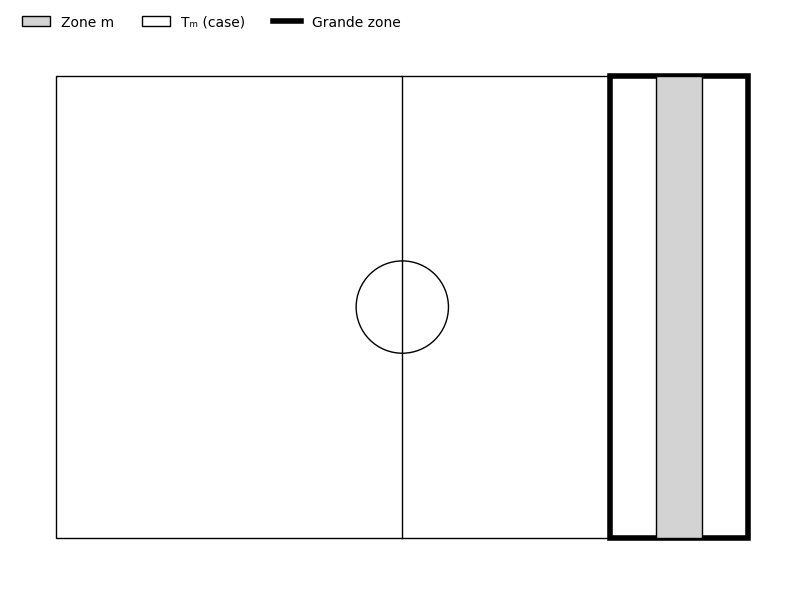

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

# 1) Création de la figure
fig, ax = plt.subplots(figsize=(9, 6))

# 2) Terrain (15×10)
terrain = Rectangle((0, 0), 15, 10,
                    edgecolor='black', facecolor='none', linewidth=1)
ax.add_patch(terrain)

# 3) Ligne médiane
ax.plot([7.5, 7.5], [0, 10], color='black', linewidth=1)

# 4) Cercle central
cercle = Circle((7.5, 5), 1.0, edgecolor='black', facecolor='none', linewidth=1)
ax.add_patch(cercle)

# 5) Grande zone (mise en gras)
#    ici on choisit de la placer sur les 3 dernières unités en x (de 12 à 15)
grande_zone = Rectangle((12, 0), 3, 10,
                        edgecolor='black', facecolor='none', linewidth=4)
ax.add_patch(grande_zone)

# 6) Zone m (1 unité de large, rembourrée en gris)
zone_m = Rectangle((13, 0), 1, 10,
                   edgecolor='black', facecolor='lightgrey', linewidth=1)
ax.add_patch(zone_m)

# 7) Ajustements et légende
ax.set_xlim(-1, 16)
ax.set_ylim(-1, 11)
ax.set_aspect('equal')
ax.axis('off')

# Légende « Zone m » et « Tₘ »
legend_elements = [
    Rectangle((0, 0), 1, 1, facecolor='lightgrey', edgecolor='black', label='Zone m'),
    Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black', label='Tₘ (case)'),
    Line2D([0], [0], color='black', lw=4, label='Grande zone')
]
ax.legend(handles=legend_elements,
          loc='upper left',
          bbox_to_anchor=(0, 1.05),
          ncol=3,
          frameon=False)

plt.tight_layout()
plt.show()


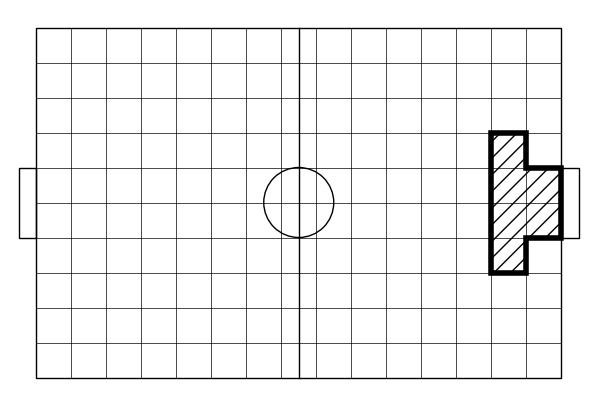

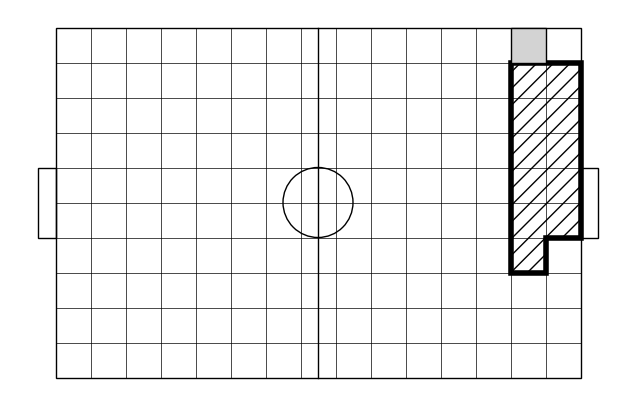

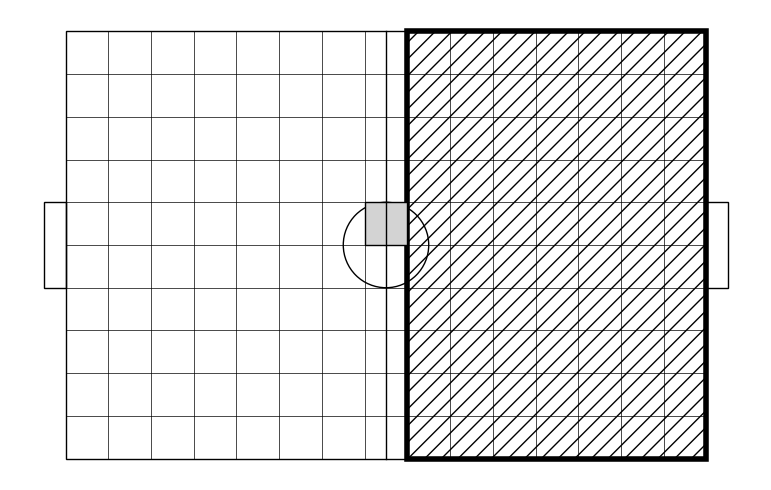

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Polygon

# dimensions du terrain
W, H = 15, 10

# ---------- Figure 1 ----------
fig1, ax = plt.subplots(figsize=(8, 5))
x1, w1 = W-3, 3
# 1) contour du terrain
ax.add_patch(Rectangle((0, 0), W, H,
                       edgecolor='black', facecolor='none', linewidth=1))

# 2) maillage 1×1
for x in range(1, W):
    ax.plot([x, x], [0, H], color='black', linewidth=0.5)
for y in range(1, H):
    ax.plot([0, W], [y, y], color='black', linewidth=0.5)

# 3) ligne médiane et cercle central
ax.plot([W/2, W/2], [0, H], color='black', linewidth=1)
ax.add_patch(Circle((W/2, H/2), 1,
                    edgecolor='black', facecolor='none', linewidth=1))

# ✅ Hachures avec densité réduite
polygon_sommets = [(13,7), (14,7), (14,6), (15,6),(15,4), (14,4), (14,3), (13,3)]
ax.add_patch(Polygon(polygon_sommets, closed=True,
                   edgecolor='black', facecolor='none', linewidth=4, hatch='//'))  # ✅ Moins de barres

ax.set_aspect('equal')
ax.axis('off')

# Rajoutons les cages des deux cotés
ax.add_patch(Rectangle((-0.5, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))
ax.add_patch(Rectangle((W, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))

# ---------- Figure 2 : Cas 1 ----------
fig2, ax = plt.subplots(figsize=(8, 5))
for x in range(1, W):
    ax.plot([x, x], [0, H], color='black', linewidth=0.5)
for y in range(1, H):
    ax.plot([0, W], [y, y], color='black', linewidth=0.5)

ax.add_patch(Rectangle((0, 0), W, H,
                       edgecolor='black', facecolor='none', linewidth=1))
ax.plot([W/2, W/2], [0, H], color='black', linewidth=1)
ax.add_patch(Circle((W/2, H/2), 1,
                    edgecolor='black', facecolor='none', linewidth=1))
ax.add_patch(Rectangle((-0.5, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))
ax.add_patch(Rectangle((W, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))

# ✅ Hachures avec densité réduite
polygon = [(13,9), (15,9), (15,4), (14,4), (14,3), (13,3)]
ax.add_patch(Polygon(polygon, closed=True,
                   edgecolor='black', facecolor='none', linewidth=4, hatch='//'))  # ✅ Moins de barres

ax.add_patch(Rectangle((x1+1, H - 1),
                       1, 1,
                       edgecolor='black', facecolor='lightgrey'))

ax.set_aspect('equal')
ax.axis('off')

# ---------- Figure 3 : Cas 2 ----------
fig3, ax = plt.subplots(figsize=(8, 5))
for x in range(1, W):
    ax.plot([x, x], [0, H], color='black', linewidth=0.5)
for y in range(1, H):
    ax.plot([0, W], [y, y], color='black', linewidth=0.5)

ax.add_patch(Rectangle((0, 0), W, H,
                       edgecolor='black', facecolor='none', linewidth=1))
ax.plot([W/2, W/2], [0, H], color='black', linewidth=1)
ax.add_patch(Circle((W/2, H/2), 1,
                    edgecolor='black', facecolor='none', linewidth=1))

x2, w2 = W*8/15, W*7/15
# ✅ Hachures avec densité réduite
ax.add_patch(Rectangle((x2, 0), w2, H,
                       edgecolor='black', facecolor='none', linewidth=4, hatch='//'))  # ✅ Moins de barres

ax.add_patch(Rectangle((x2-1, H /2),
                       1, 1,
                       edgecolor='black', facecolor='lightgrey'))
ax.add_patch(Rectangle((-0.5, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))
ax.add_patch(Rectangle((W, (H-2)/2), 0.5, 2,
                       edgecolor='black', facecolor='none', linewidth=1))

ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.colors import LinearSegmentedColormap
import os
os.chdir(r"C:\Users\az_ta\Documents\Stage 3A Japon\Determiner_f\src")
from pass_predictor import PassPredictor

def create_pitch(ax):
    """Dessine un terrain de football normalisé (0-1)"""
    ax.add_patch(Rectangle((0, 0), 1, 1, edgecolor='black', facecolor='#538032', lw=2, alpha=0.2))
    ax.plot([0.5, 0.5], [0, 1], color='white', lw=2)
    ax.add_patch(Circle((0.5, 0.5), 0.1, edgecolor='white', facecolor='none', lw=2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    return ax

def plot_player(ax, x, y, color, label=None, size=200, zorder=3):
    ax.scatter(x, y, s=size, color=color, edgecolor='black', zorder=zorder)
    if label:
        ax.text(x, y, label, ha='center', va='center', color='white', fontsize=10, fontweight='bold', zorder=zorder+1)

def plot_ball(ax, x, y):
    ax.scatter(x, y, s=80, color='orange', edgecolor='black', zorder=5)

def plot_pass_heatmap_passpredictor(ax, x_passeur, y_passeur, adv_positions, teammate_positions, predictor):
    """Affiche la heatmap de probabilité de passe avec PassPredictor"""
    x_grid = np.linspace(0.05, 0.95, 30)
    y_grid = np.linspace(0.05, 0.95, 20)
    prob_matrix = np.zeros((len(y_grid), len(x_grid)))
    for i, y_cible in enumerate(y_grid):
        for j, x_cible in enumerate(x_grid):
            features = predictor.calculate_pass_features(
                x_passeur, y_passeur, x_cible, y_cible,
                teammates_pos=teammate_positions,
                opponents_pos=adv_positions
            )
            import pandas as pd
            feature_df = pd.DataFrame([features])
            prob = predictor.predict_pass_success(feature_df)[0]
            prob_matrix[i, j] = prob
    X, Y = np.meshgrid(x_grid, y_grid)
    cmap = LinearSegmentedColormap.from_list('custom', ['red', 'yellow', 'green'], N=100)
    contour = ax.contourf(X, Y, prob_matrix, levels=50, cmap=cmap, alpha=0.6)
    plt.colorbar(contour, ax=ax, shrink=0.8, label='Probabilité de réussite')
    return prob_matrix

def show_typical_situation_passpredictor(predictor):
    """Affiche une situation typique avec joueurs, ballon et heatmap (PassPredictor)"""
    x_passeur, y_passeur = 0.25, 0.5
    adv_positions = np.array([
        [0.7, 0.3], [0.7, 0.7], [0.5, 0.5], [0.6, 0.4], [0.6, 0.6]
    ])
    teammate_positions = np.array([
        [0.4, 0.5], [0.3, 0.3], [0.3, 0.7], [0.5, 0.3], [0.5, 0.7]
    ])

    fig, ax = plt.subplots(figsize=(10, 7))
    create_pitch(ax)
    plot_player(ax, x_passeur, y_passeur, 'blue', label='⚽', size=250)
    for x, y in adv_positions:
        plot_player(ax, x, y, 'red')
    for x, y in teammate_positions:
        plot_player(ax, x, y, 'dodgerblue')
    plot_ball(ax, x_passeur, y_passeur)
    plot_pass_heatmap_passpredictor(ax, x_passeur, y_passeur, adv_positions, teammate_positions, predictor)
    plt.title("Situation typique : probabilité de réussite de passe (modèle)", fontsize=14)
    plt.tight_layout()
    plt.show()

# Utilisation :
# predictor = PassPredictor().load_model()
# show_typical_situation_passpredictor(predictor)
# ...existing code...


In [9]:
predict = PassPredictor().load_model()
show_typical_situation_passpredictor(predict)

Attention: best_params.json non trouvé


FileNotFoundError: Aucun modèle best_pass_model_* trouvé